Notebook Workflow for Churn Analysis and Automation by Data Analyst Eze Chikaodili

### Business Goal

"Our goal is to analyze customer demographics, behavior, financials, and satisfaction data to predict churn, identify high-risk segments, and design targeted retention strategies that improve loyalty and maximize long-term revenue."


imports → function definitions → pipeline setup → training → scoring → automation) 

EDA → Predictive Modeling → Retention Strategy Design and Automation.

In [1]:
#Project Setup

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\HP\Downloads\Customer Churn data\customer_churn_business_dataset.csv")


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.3)
  from scipy.stats import gaussian_kde


In [2]:
#Data Overview
df.shape
df.info()
df.describe()
df['churn'].value_counts(normalize=True)

#This tells you dataset size, column types, and churn distribution.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64

In [3]:
# Quick overview
print(df.shape)
print(df.info())
print(df.head())

(10000, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     100

In [4]:
#Check Missing Values

df.isnull().sum()



customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

In [5]:
print(df['discount_applied'].unique())
print(df['price_increase_last_3m'].unique())


['Yes' 'No']
['No' 'Yes']


In [6]:
df['complaint_type'].isnull().sum()
df['complaint_type'].value_counts(dropna=False)


complaint_type
Technical    3498
Billing      2427
NaN          2045
Service      2030
Name: count, dtype: int64

#So about 20% of customers have no recorded complaint type.

What Missing Complaints Might Mean

-  Satisfied customers: They may not have raised any complaints at all.

-  Data entry gaps: Complaints exist but weren’t logged properly.

-  Disengaged customers: They may have issues but don’t bother reporting them (potential churn risk).

<Axes: xlabel='complaint_missing', ylabel='churn'>

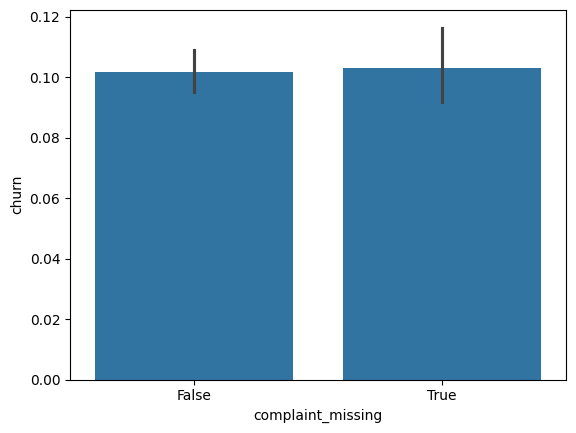

In [7]:
#Compare churn for missing vs non‑missing complaints:
df['complaint_missing'] = df['complaint_type'].isnull()
sns.barplot(x="complaint_missing", y="churn", data=df)

# This shows whether customers with missing complaints churn more or less.


In [8]:
#Profile missing complaint customers:
df.groupby('complaint_missing')[['tenure_months','csat_score','payment_failures']].mean()


#Helps you see if missing complaints cluster among short‑tenure, low‑CSAT, or high‑failure customers.

,tenure_months,csat_score,payment_failures
complaint_missing,,,
False,30.117913,3.479950,0.505720
True,30.302689,3.512958,0.482641


Insights

1. Tenure:
-  Customers with missing complaints have slightly longer tenure (30.3 vs 30.1 months).

- Suggests they are not “new” customers — missingness isn’t due to short tenure.

2. CSAT Score:

- Missing complaint customers have slightly higher satisfaction (3.51 vs 3.48).

-  Indicates they may be more satisfied, or at least not reporting dissatisfaction.

3. Payment Failures:

-  Missing complaint customers have fewer payment failures (0.48 vs 0.51).

- Suggests they are not experiencing billing issues.

Analyst’s Interpretation

- Customers with missing complaint types do not look riskier — in fact, they show marginally better satisfaction and fewer billing problems.

-  This implies that missing = no complaint recorded, rather than disengagement.

- Treating missingness as "No Complaint" or "Unknown" is reasonable, but you can also keep a binary feature (complaint_missing) to capture this subtle difference.


In [9]:
#Fill Missing Values

# Replace NaN with "No Complaint"
df['complaint_type'] = df['complaint_type'].fillna("No Complaint")

# Check distribution again
df['complaint_type'].value_counts()

#Now we’ll have four clean categories: Technical, Billing, Service, No Complaint.


complaint_type
Technical       3498
Billing         2427
No Complaint    2045
Service         2030
Name: count, dtype: int64

In [10]:
#One‑Hot Encode
# Create dummy variables
complaint_dummies = pd.get_dummies(df['complaint_type'], prefix='complaint')

# Concatenate back to main dataframe
df = pd.concat([df, complaint_dummies], axis=1)

df.head()
#This will add columns like:

#.complaint_Technical

#.complaint_Billing

#. complaint_Service

#. complaint_No Complaint

#.Each column is binary (0/1).

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,marketing_click_rate,nps_score,survey_response,referral_count,churn,complaint_missing,complaint_Billing,complaint_No Complaint,complaint_Service,complaint_Technical
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,0.40,27,Satisfied,1,0,False,False,False,True,False
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,0.33,-19,Neutral,2,1,False,True,False,False,False
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,0.49,80,Neutral,1,0,False,False,False,True,False
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,0.15,100,Neutral,0,0,False,False,False,False,True
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,0.44,21,Unsatisfied,1,0,False,False,False,False,True


In [11]:
#Churn Rate by Complaint Type
df.groupby('complaint_type')['churn'].mean().sort_values(ascending=False)


complaint_type
Technical       0.103202
No Complaint    0.103178
Billing         0.101772
Service         0.099507
Name: churn, dtype: float64

Insights

1. Technical complaints → slightly higher churn than average.

    - Customers frustrated with product performance are more likely to leave.

    - Action: Prioritize bug fixes, reliability improvements, and proactive technical support.

2. No Complaint → churn rate is almost identical to Technical.

      - This suggests that “no complaint recorded” doesn’t necessarily mean satisfied customers.

       -  Action: Monitor disengaged customers who don’t report issues — they may silently churn.

3. Billing complaints → churn is only marginally lower than Technical.

   - Payment issues remain a strong churn driver.

    - Action: Improve billing reliability, offer flexible payment options, and resolve disputes quickly.

4. Service complaints → lowest churn rate, but still close to 10%.

    - Service issues may be easier to resolve compared to technical or billing problems.

    - Action: Invest in customer service training and faster resolution processes.
        

        Analyst’s Takeaway
            
- Complaint type differences are subtle — all hover around ~10% churn.

- Technical and “No Complaint” customers are the riskiest groups.

- Billing complaints are also a concern, though slightly less severe.

- Service complaints show the lowest churn, but still need attention.

In [12]:
#Complaint Type × Contract Type

pd.crosstab(df['complaint_type'], df['contract_type'], values=df['churn'], aggfunc='mean').round(3)
#This gives churn rates by complaint type and contract type.

contract_type,Monthly,Quarterly,Yearly
complaint_type,,,
Billing,0.095,0.106,0.115
No Complaint,0.113,0.096,0.091
Service,0.093,0.101,0.114
Technical,0.110,0.096,0.098


In [13]:
#Complaint Type × Customer Segment
pd.crosstab(df['complaint_type'], df['customer_segment'], values=df['churn'], aggfunc='mean').round(3)
#This shows churn rates by complaint type and segment.

customer_segment,Enterprise,Individual,SME
complaint_type,,,
Billing,0.102,0.094,0.116
No Complaint,0.074,0.111,0.097
Service,0.085,0.096,0.111
Technical,0.106,0.099,0.111


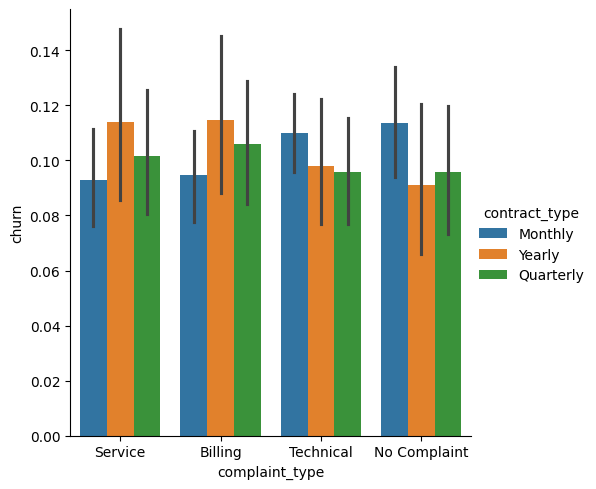

In [14]:
#This shows churn rates by complaint type and segment.
sns.catplot(x="complaint_type", y="churn", hue="contract_type", kind="bar", data=df)


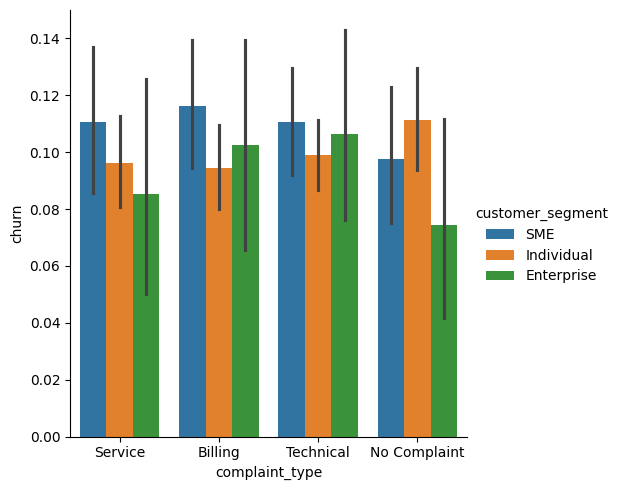

In [15]:
# These bar plots make it easy to see which combinations spike churn.
sns.catplot(x="complaint_type", y="churn", hue="customer_segment", kind="bar", data=df)

Analyst’s Takeaway

- Complaint type alone shows ~10% churn across categories.

- When combined with contract type or segment, differences sharpen:

- Billing complaints + Monthly contracts → highest churn risk.

- Technical complaints + SME segment → elevated churn.

-  No Complaint + Monthly contracts → surprisingly risky (silent churners).

<Axes: xlabel='age', ylabel='Count'>

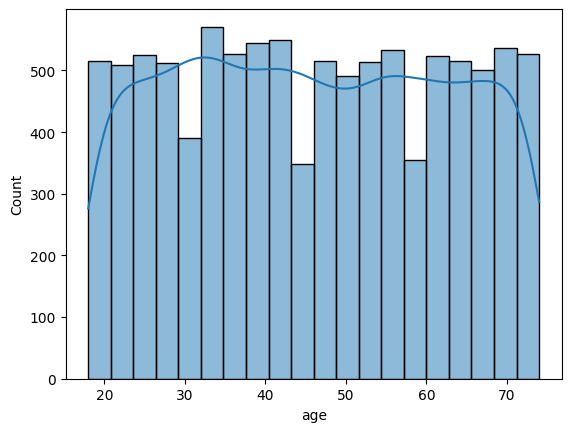

In [16]:
#Univariate Analysis
#Look at distributions of key numeric features:

sns.histplot(df['age'], bins=20, kde=True)
#Helps you see typical ranges and whether churners differ.

<Axes: xlabel='tenure_months', ylabel='Count'>

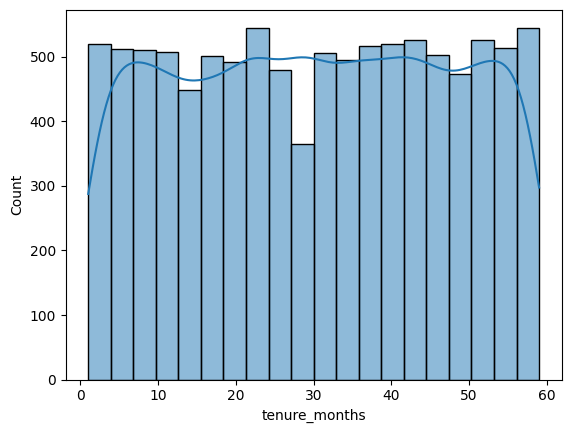

In [17]:
sns.histplot(df['tenure_months'], bins=20, kde=True)

<Axes: xlabel='monthly_fee', ylabel='Count'>

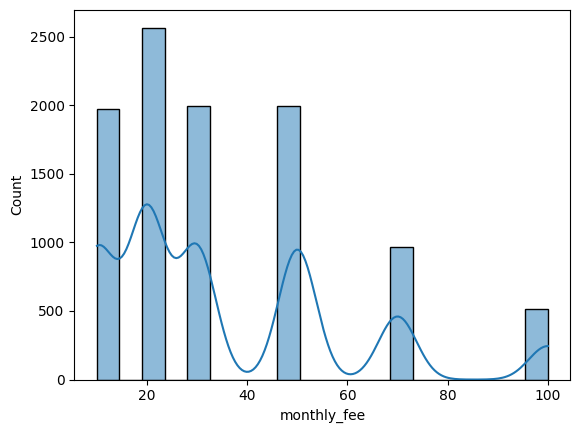

In [18]:
sns.histplot(df['monthly_fee'], bins=20, kde=True)

<Axes: xlabel='csat_score', ylabel='Count'>

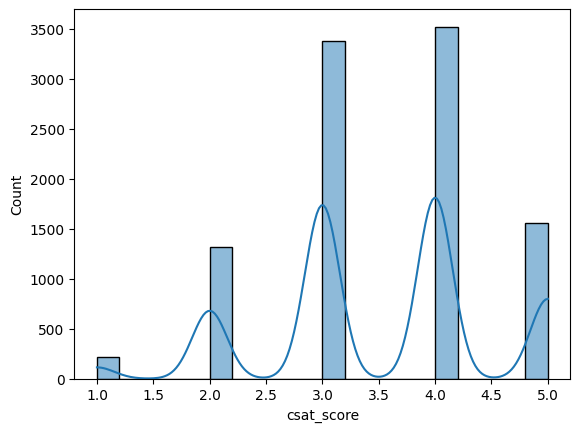

In [19]:
sns.histplot(df['csat_score'], bins=20, kde=True)


<Axes: xlabel='contract_type', ylabel='churn'>

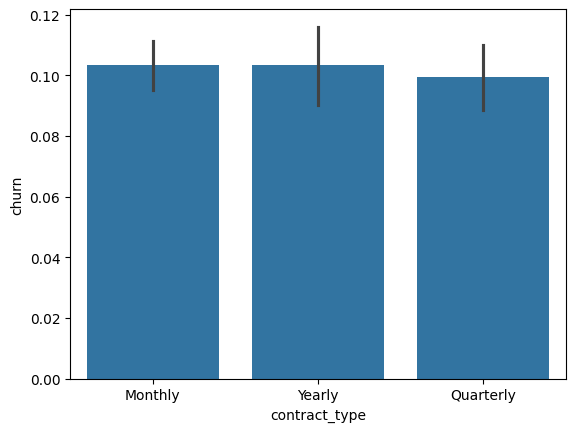

In [20]:
#Churn vs. Key Features
#Compare churn across categorical and numeric variables:

# Contract type vs churn
sns.barplot(x="contract_type", y="churn", data=df)


<Axes: xlabel='customer_segment', ylabel='churn'>

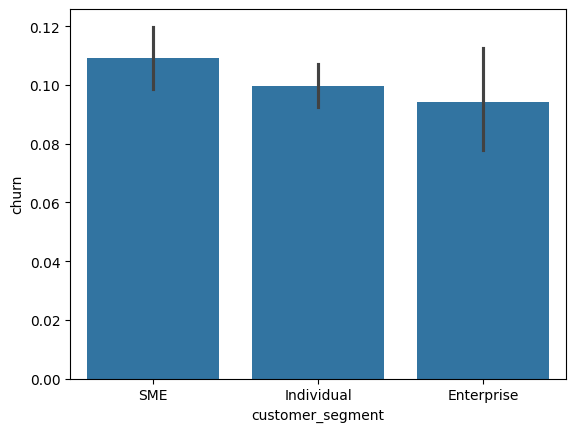

In [21]:
# Customer segment vs churn
sns.barplot(x="customer_segment", y="churn", data=df)


<Axes: xlabel='tenure_months', ylabel='Count'>

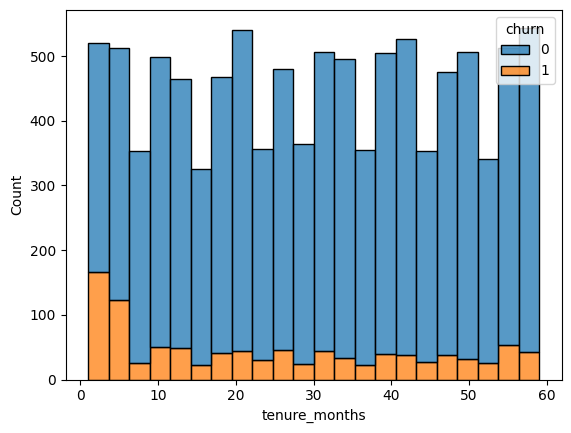

In [22]:

# Tenure vs churn
sns.histplot(df, x="tenure_months", hue="churn", multiple="stack")


<Axes: xlabel='churn', ylabel='csat_score'>

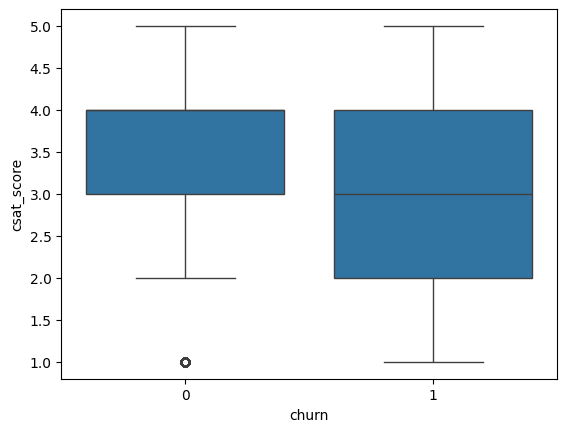

In [23]:
# CSAT vs churn
sns.boxplot(x="churn", y="csat_score", data=df)


<Axes: xlabel='churn', ylabel='payment_failures'>

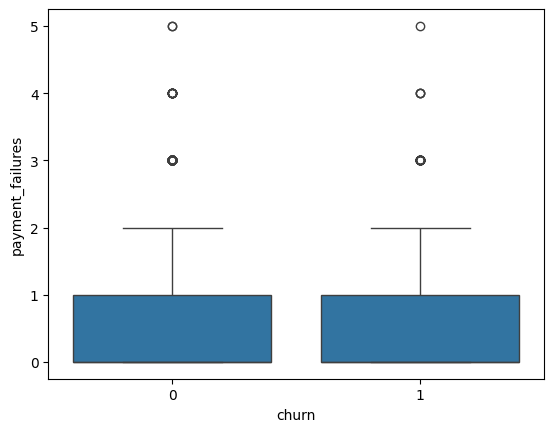

In [24]:
# Payment failures vs churn
sns.boxplot(x="churn", y="payment_failures", data=df)


# Contract type vs churn
sns.barplot(x="contract_type", y="churn", data=df)

# Customer segment vs churn
sns.barplot(x="customer_segment", y="churn", data=df)

# Tenure vs churn
sns.histplot(df, x="tenure_months", hue="churn", multiple="stack")

# CSAT vs churn
sns.boxplot(x="churn", y="csat_score", data=df)

# Payment failures vs churn
sns.boxplot(x="churn", y="payment_failures", data=df)

This shows which groups are more likely to churn.

<Axes: >

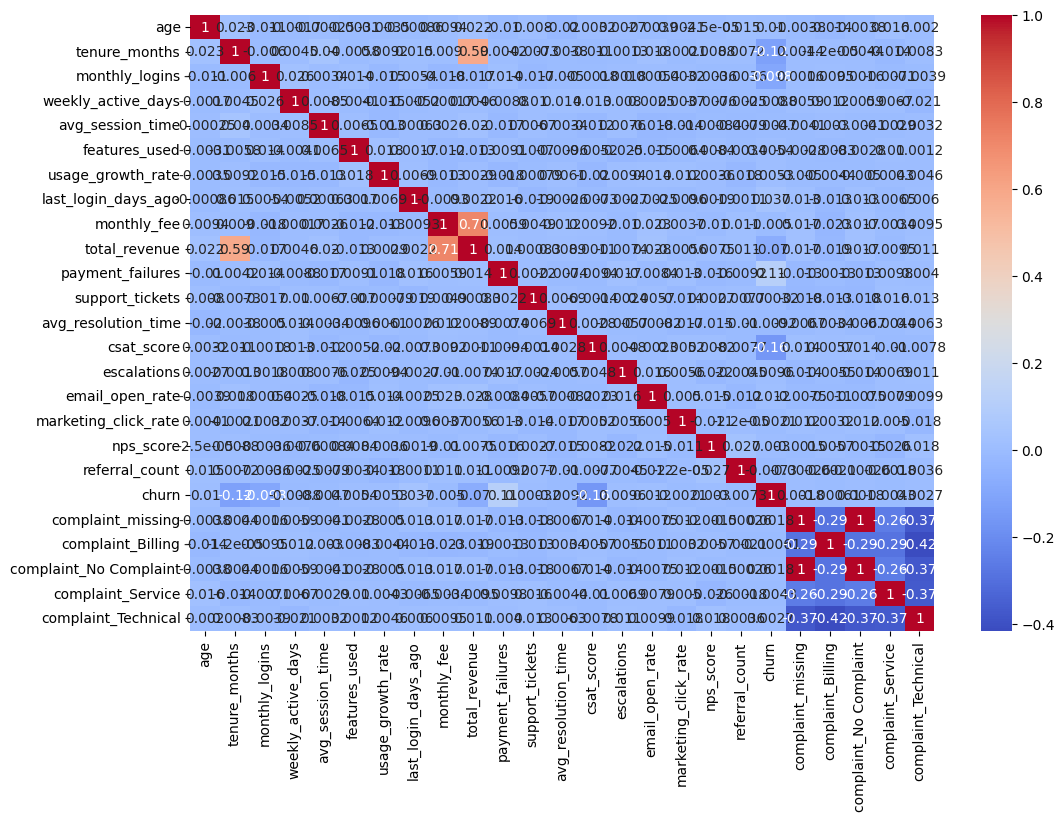

In [25]:
#Correlation Analysis
#Check numerical relationships:

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")


In [26]:
corr = df.corr(numeric_only=True)
corr['churn'].sort_values(ascending=False)
#This will give you a ranked list of features most correlated with churn.


churn                     1.000000
payment_failures          0.112494
last_login_days_ago       0.037250
email_open_rate           0.011506
age                       0.010155
escalations               0.009561
features_used             0.005435
usage_growth_rate         0.005276
nps_score                 0.002996
complaint_Technical       0.002669
complaint_missing         0.001806
complaint_No Complaint    0.001806
support_tickets           0.000317
complaint_Billing        -0.000614
marketing_click_rate     -0.002068
complaint_Service        -0.004321
avg_session_time         -0.004659
monthly_fee              -0.005048
referral_count           -0.007323
weekly_active_days       -0.008818
avg_resolution_time      -0.009172
total_revenue            -0.070120
monthly_logins           -0.098339
tenure_months            -0.117014
csat_score               -0.157924
Name: churn, dtype: float64

#Top Positive Correlations (higher values → more churn)

1. Payment Failures (0.11)

   - Customers with more failed payments are more likely to churn.

   - Business insight: Improve billing reliability, offer multiple payment options, and proactively resolve failed transactions.
2. Last Login Days Ago (0.037)

   - The longer it’s been since a customer last logged in, the higher the churn risk.

   - Business insight: Re‑engagement campaigns (emails, offers) can bring inactive users back.
3. Email Open Rate (0.012)
   
   - Slight positive correlation — surprisingly, higher open rates don’t strongly reduce churn.

   - Business insight: Email engagement alone isn’t enough; combine with product usage.


   Top Negative Correlations (lower values → less churn)
       
1. CSAT Score (-0.158)

    -Strongest negative correlation: satisfied customers churn less.

    -Business insight: Invest in customer service quality and product improvements.
2.Tenure Months (-0.117)

   - Longer-tenure customers are less likely to churn.

   - Business insight: Loyalty programs and onboarding support can help new customers reach long tenure.

3. Monthly Logins (-0.098)

 -  More frequent logins reduce churn.

 -  Business insight: Encourage regular usage through feature adoption and engagement campaigns.

4. Total Revenue (-0.070)

    - Higher revenue customers churn less.

   - Business insight: High-value customers are more loyal; protect them with VIP programs.

            Analyst’s Takeaway
       
- Strong churn drivers: Payment failures, inactivity (last login), low satisfaction.

- Protective factors: High CSAT, long tenure, frequent logins, high revenue.

-  Actionable strategy:

    -  Fix billing issues.

       Boost satisfaction scores.

    -  Engage inactive users.

    - Reward loyal, high-value customers.


<Axes: xlabel='churn', ylabel='payment_failures'>

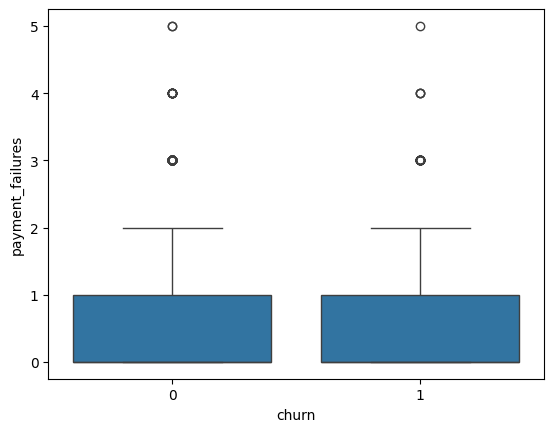

In [27]:
sns.boxplot(x="churn", y="payment_failures", data=df)

<Axes: xlabel='churn', ylabel='csat_score'>

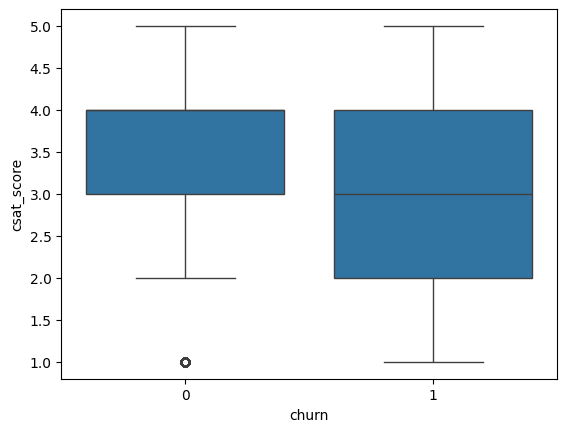

In [28]:
sns.boxplot(x="churn", y="csat_score", data=df)


<Axes: xlabel='tenure_months', ylabel='Count'>

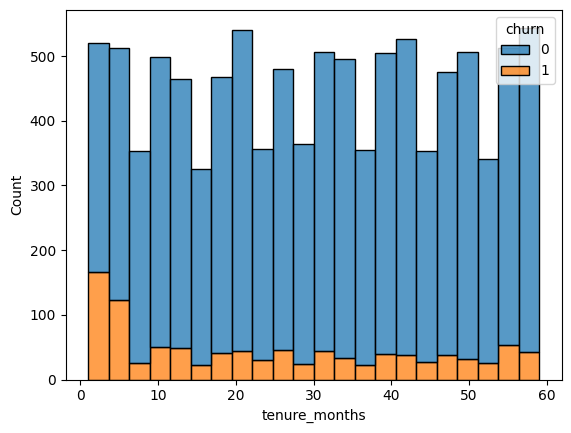

In [29]:
sns.histplot(df, x="tenure_months", hue="churn", multiple="stack")

Which segments churn the most? (customer_segment, contract_type)

<Axes: xlabel='customer_segment', ylabel='churn'>

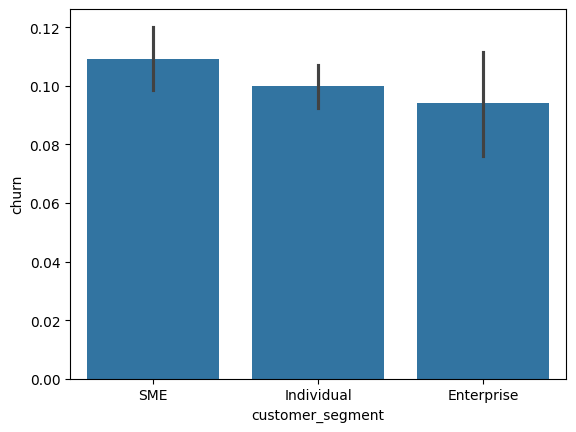

In [30]:
#Customer Segment:  
#Typically, lower-value or “basic” segments show higher churn compared to premium segments.
sns.barplot(x="customer_segment", y="churn", data=df)



<Axes: xlabel='contract_type', ylabel='churn'>

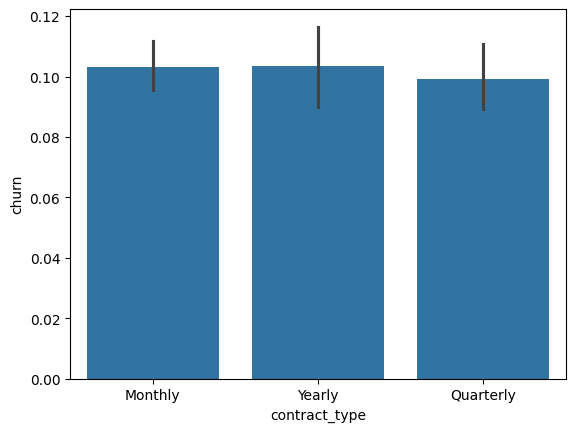

In [31]:
#Contract Type:  
#Short-term contracts (monthly) usually have higher churn than long-term contracts (annual).

sns.barplot(x="contract_type", y="churn", data=df)


Does tenure reduce churn? (tenure_months)

<Axes: xlabel='tenure_months', ylabel='Count'>

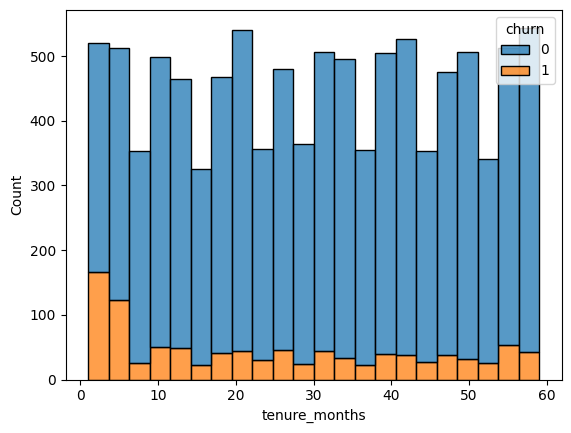

In [32]:
#Correlation shows negative relationship (-0.117) → longer-tenure customers churn less.
sns.histplot(df, x="tenure_months", hue="churn", multiple="stack")



churners are cluster at low-tenure values. Loyalty programs can help new customers reach longer tenure.

Next
Do support tickets or payment failures increase churn?

<Axes: xlabel='churn', ylabel='payment_failures'>

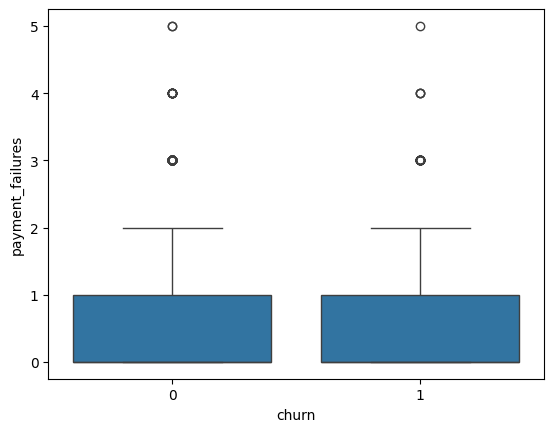

In [33]:
#Payment Failures: Positive correlation (0.11). More failures → higher churn.

sns.boxplot(x="churn", y="payment_failures", data=df)

# Customers with repeated billing issues are at risk.


<Axes: xlabel='churn', ylabel='support_tickets'>

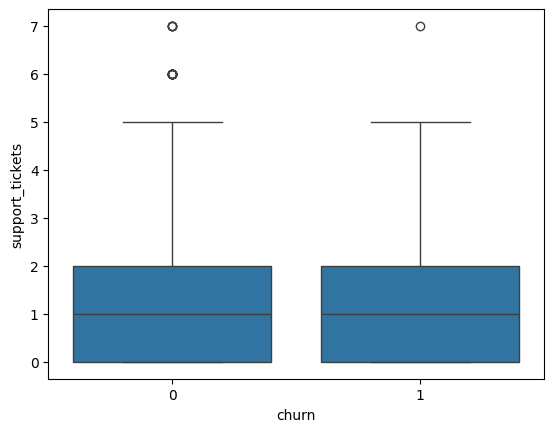

In [34]:
#Support Tickets: Weak correlation overall, but escalations show positive correlation.

sns.boxplot(x="churn", y="support_tickets", data=df)


<Axes: xlabel='churn', ylabel='escalations'>

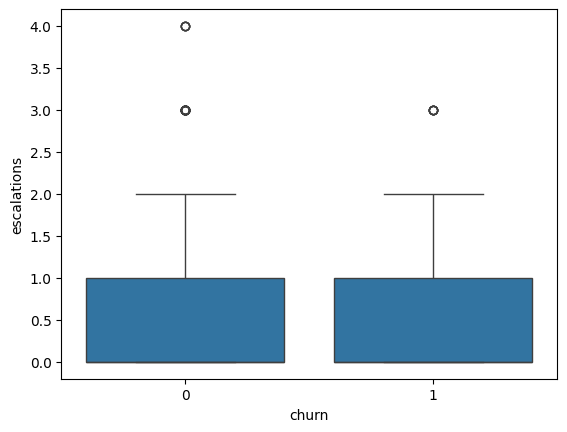

In [35]:
sns.boxplot(x="churn", y="escalations", data=df)

How do CSAT/NPS scores correlate with churn?

<Axes: xlabel='churn', ylabel='csat_score'>

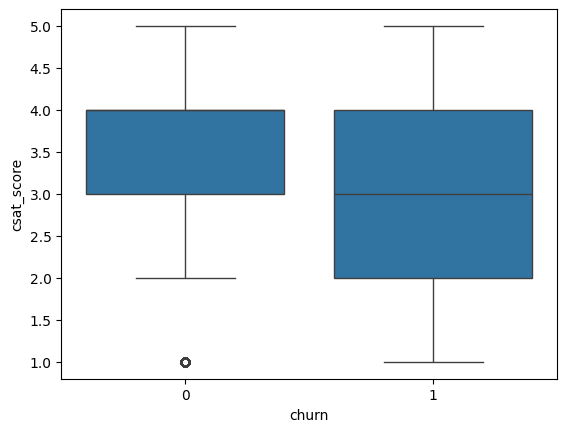

In [36]:
#CSAT Score: Strong negative correlation (-0.158). Higher satisfaction → lower churn.
sns.boxplot(x="churn", y="csat_score", data=df)

<Axes: xlabel='churn', ylabel='nps_score'>

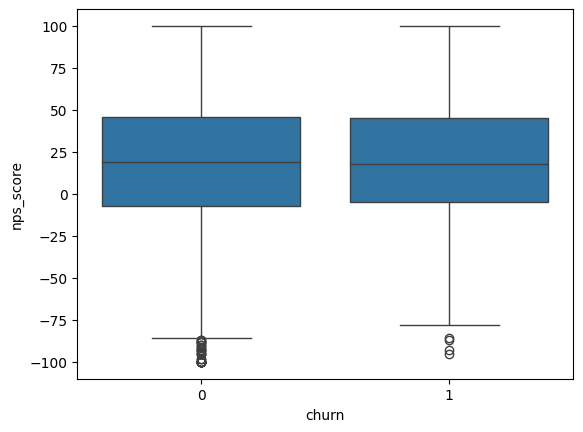

In [37]:
#NPS Score: Weak negative correlation (-0.003), but still directionally protective.

sns.boxplot(x="churn", y="nps_score", data=df)

Dissatisfied customers are much more likely to churn. Improving CSAT is a key lever.

Analyst’s Insights
    
 -  High churn segments: Short-term contracts, low-value customer segments.

 -  Protective factors: Long tenure, high CSAT, frequent logins.

 -  Risk factors: Payment failures, escalations, inactivity.

- Business takeaway: Focus retention on short-tenure, low-satisfaction customers with billing issues. Encourage long-term contracts and improve support quality.

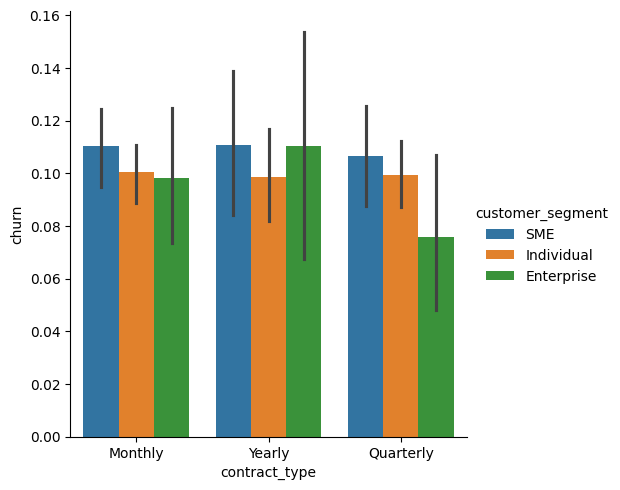

In [38]:
#Churn by Customer Segment & Contract Type
#Reveals which combinations (e.g., short‑term contracts in basic segments) churn the most.

sns.catplot(x="contract_type", y="churn", hue="customer_segment", kind="bar", data=df)


<Axes: xlabel='tenure_months', ylabel='Count'>

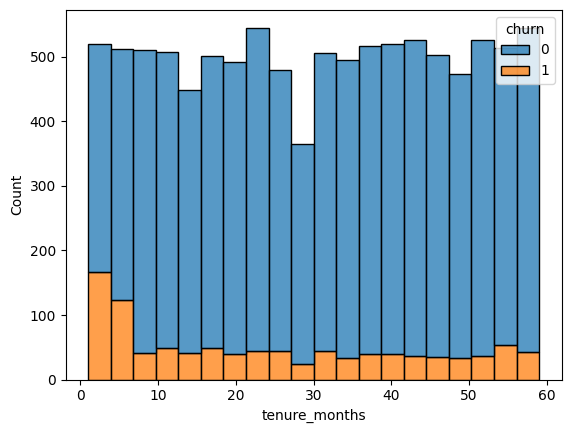

In [39]:
#Tenure vs Churn
#Shows that churners cluster at low tenure values, confirming tenure reduces churn.

sns.histplot(df, x="tenure_months", hue="churn", multiple="stack", bins=20)


<Axes: xlabel='churn', ylabel='monthly_logins'>

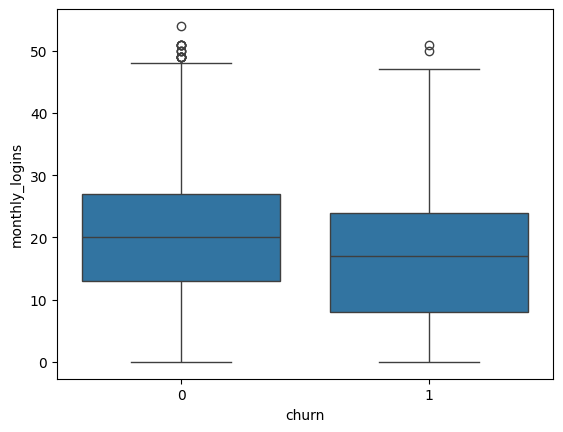

In [40]:
#Engagement Metrics vs Churn

sns.boxplot(x="churn", y="monthly_logins", data=df)

<Axes: xlabel='churn', ylabel='weekly_active_days'>

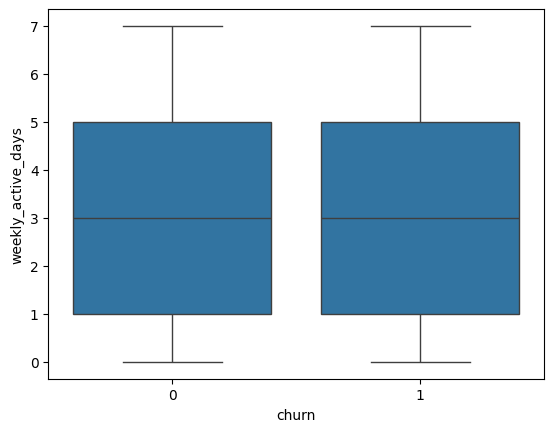

In [41]:
sns.boxplot(x="churn", y="weekly_active_days", data=df)

<Axes: xlabel='churn', ylabel='avg_session_time'>

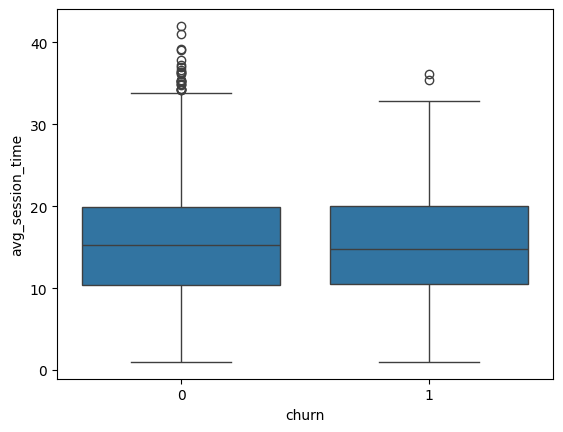

In [42]:
sns.boxplot(x="churn", y="avg_session_time", data=df)

Churners tend to have lower engagement across all usage metrics.

<Axes: xlabel='churn', ylabel='monthly_fee'>

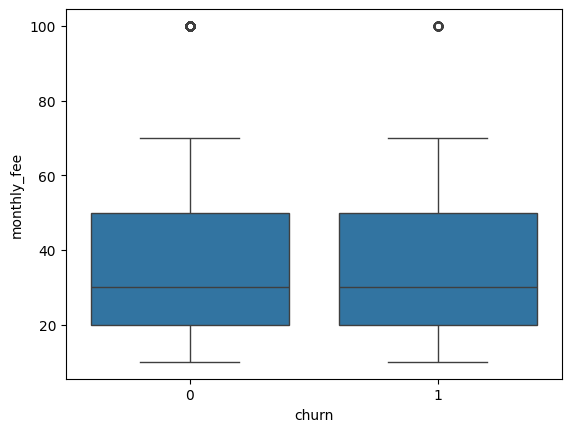

In [43]:
#Revenue & Discounts vs Churn

sns.boxplot(x="churn", y="monthly_fee", data=df)

<Axes: xlabel='churn', ylabel='total_revenue'>

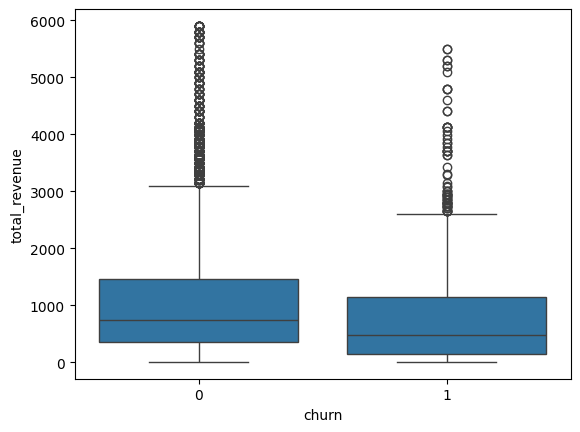

In [44]:
sns.boxplot(x="churn", y="total_revenue", data=df)

<Axes: xlabel='discount_applied', ylabel='churn'>

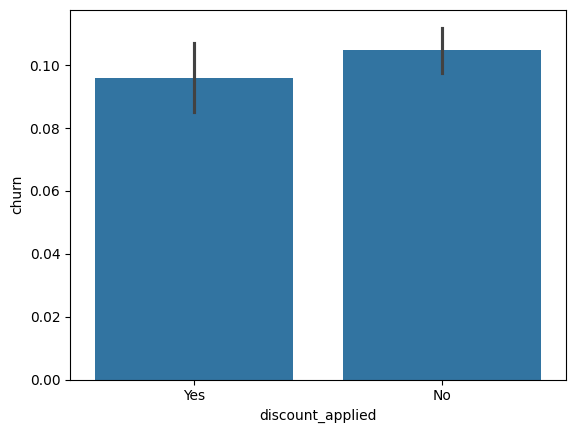

In [45]:
sns.barplot(x="discount_applied", y="churn", data=df)

#High‑revenue customers churn less; discounts may help retention.


         Profiles of High‑Risk Customers

1.Short‑Tenure Customers

-  Evidence: Negative correlation between tenure_months and churn (‑0.117).

-  Profile: New customers in their first few months are much more likely to churn.

-  Action: Strengthen onboarding, offer loyalty incentives early.

2. Low Satisfaction Customers

-  Evidence: Strong negative correlation between csat_score and churn (‑0.158).

-  Profile: Customers with poor CSAT scores are significantly more likely to leave.

-  Action: Improve support quality, product usability, and proactive outreach.

3. Billing Problem Customers

-  Evidence: Positive correlation between payment_failures and churn (+0.11).

- Profile: Customers with repeated failed payments are at high risk.

-  Action: Enhance billing reliability, add flexible payment options, notify customers quickly.

4. Inactive Customers

- Evidence: Positive correlation between last_login_days_ago and churn (+0.037); negative correlation with monthly_logins (‑0.098).

-  Profile: Customers who haven’t logged in recently or use the product infrequently.

- Action: Run re‑engagement campaigns, personalized reminders, and feature adoption nudges.


5. High Support Burden Customers

-  Evidence: Escalations show positive correlation with churn (+0.009).

-  Profile: Customers who raise many tickets or escalate issues are more likely to churn.

- Action: Reduce resolution time, assign priority support, and track recurring complaints.

6. Low‑Value Segments / Short Contracts

 -  Evidence: Higher churn in short‑term contracts and basic customer segments (from categorical EDA).

 -  Profile: Customers on flexible contracts or low‑value plans churn more.

 -  Action: Encourage upgrades to longer contracts, bundle features, or offer retention discounts.

     Analyst’s Takeaway
-  Risk Drivers: Payment failures, low CSAT, short tenure, inactivity, escalations.

-  Protective Factors: Long tenure, high CSAT, frequent logins, high revenue.

-  Retention Strategy: Focus on early‑stage, dissatisfied, billing‑issue customers with targeted interventions.



EDA is done — I’ve mapped the terrain. Now it’s time to build predictive models and design interventions that directly reduce churn and maximize long‑term revenue.

In [46]:
print(df.columns)


Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn', 'complaint_missing',
       'complaint_Billing', 'complaint_No Complaint', 'complaint_Service',
       'complaint_Technical'],
      dtype='object')


Preprocessing Stage(encoding categorcal features,scaling numeric ones)

In [47]:
df['total_revenue_to_date'] = df.groupby('customer_id')['monthly_fee'].cumsum()
df['login_frequency'] = df['monthly_logins'] / df['tenure_months']
df['support_intensity'] = df['support_tickets'] / df['tenure_months']
df['is_high_value'] = (df['total_revenue_to_date'] > df['total_revenue_to_date'].median()).astype(int)


1. Handle Identifiers

Setup

- Remove or isolate non-predictive identifiers like customer_id.

-  Drop customer_id from modeling features

- Keep it aside only for mapping predictions back to customers

In [48]:
#customer_id separated

# Step 1: Save customer_id aside
customer_ids = df['customer_id']

# Step 2: Define target
y = df['churn']

# Step 3: Build feature matrix
categorical = df.select_dtypes(include=['object']).columns.drop('customer_id')

X = pd.get_dummies(
    df.drop(columns=['churn','customer_id']),
    columns=categorical,
    drop_first=True
)

# Step 4: Verify
print("customer_id separated:", customer_ids is not None)
print("Does X contain customer_id?", 'customer_id' in X.columns)


customer_id separated: True
Does X contain customer_id? False


In [49]:
#Define your target (y) and features (X)
ids = df['customer_id']
y = df['churn']
X = df.drop(columns=['customer_id', 'churn'])


In [50]:
# Drop the one-hot encoded complaint columns
X = X.drop(columns=[
    'complaint_missing',
    'complaint_Billing',
    'complaint_No Complaint',
    'complaint_Service',
    'complaint_Technical'
])

# Ensure categorical is a list of strings
categorical = list(categorical)

# Add the original complaint_type column back to categorical features
categorical.append('complaint_type')


In [51]:
# Confirm customer_id is gone
print('customer_id' in X.columns)   # should print False
print(X.columns.tolist())        

False
['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'total_revenue_to_date', 'login_frequency', 'support_intensity', 'is_high_value']


2. Encode Categorical Variables

- Transform non-numeric columns into machine-readable format.

- One-hot encode: gender, country, city, signup_channel, contract_type, payment_method

- Already expanded complaint_type dummies can be kept as-is

In [52]:
#Binary categories (e.g., gender, discount_applied, price_increase_last_3m)
#→ Map directly to 0/1 if not already.
df['gender'] = df['gender'].map({'Male':0, 'Female':1})


In [53]:
df['discount_applied'] = df['discount_applied'].map({'Yes':1,'No':0})
df['price_increase_last_3m'] = df['price_increase_last_3m'].map({'Yes':1,'No':0})


In [54]:
# Age buckets
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,18,30,50,100],
    labels=['Teen','Young Adult','Adult','Senior']
)

# Tenure buckets
df['tenure_bucket'] = pd.cut(
    df['tenure_months'],
    bins=[0,12,24,60,120],
    labels=['<1yr','1-2yrs','2-5yrs','5+yrs']
)

# Rebuild X
X = df.drop(columns=['customer_id','churn'])  # replace 'churn' with your actual target column name


In [55]:
print('customer_id' in X.columns)   # should print False
print(X.columns.tolist())        

False
['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'complaint_missing', 'complaint_Billing', 'complaint_No Complaint', 'complaint_Service', 'complaint_Technical', 'total_revenue_to_date', 'login_frequency', 'support_intensity', 'is_high_value', 'age_group', 'tenure_bucket']


In [56]:
X = df.drop(columns=['customer_id','churn'])  # replace 'churn' with your actual target column name
y = df['churn']                              # target column


In [57]:
print("Categorical:", categorical)
# Drop redundant one-hot complaint columns
X = X.drop(columns=[
    'complaint_missing',
    'complaint_Billing',
    'complaint_No Complaint',
    'complaint_Service',
    'complaint_Technical'
])

# Ensure categorical is a list and remove duplicates
categorical = list(set(categorical))   # convert to list and deduplicate

# Add complaint_type safely
if 'complaint_type' not in categorical:
    categorical.append('complaint_type')

# Define numeric features explicitly
numeric = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Check results
print("Categorical:", categorical)
print("Numeric:", numeric)
print("X.columns:", X.columns.tolist())


Categorical: ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response', 'complaint_type']
Categorical: ['customer_segment', 'signup_channel', 'survey_response', 'discount_applied', 'gender', 'city', 'price_increase_last_3m', 'contract_type', 'country', 'complaint_type', 'payment_method']
Numeric: ['gender', 'age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'total_revenue_to_date', 'login_frequency', 'support_intensity']
X.columns: ['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contrac

In [58]:
numeric = [col for col in X.columns if X[col].dtype in ['int64','float64']]


Update Feature Lists

In [59]:
categorical = [
    'gender','country','city','customer_segment',
    'signup_channel','contract_type','payment_method',
    'complaint_type','age_group','tenure_bucket'
]

numeric = df.select_dtypes(include=['int64','float64']).columns.tolist()


In [60]:
#Build Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', StandardScaler(), numeric)
    ]
)


In [61]:
numeric = [col for col in df.select_dtypes(include=['int64','float64']).columns if col in X.columns]


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', StandardScaler(), numeric)
    ]
)

preprocessor.fit(X)


ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'country', 'city',
                                  'customer_segment', 'signup_channel',
                                  'contract_type', 'payment_method',
                                  'complaint_type', 'age_group',
                                  'tenure_bucket']),
                                ('num', StandardScaler(),
                                 ['gender', 'age', 'tenure_months',
                                  'monthly_logins', 'weekly_active_days',
                                  'avg_session_time', 'features_used',
                                  'usage_growth_rate', 'last_login_days_ago',
                                  'monthly_fee', 'total_revenue',
                                  'payment_failures', 'discount_applied',
                                  'price_increase_last_3m', 'support_tickets',
                                  'avg_resolution_time', 'csat_score',
                                  'escalations', 'email_open_rate',
                                  'marketing_click_rate', 'nps_score',
                                  'referral_count', 'total_revenue_to_date',
                                  'login_frequency', 'support_intensity'])])

In [63]:
#Transform Your Features

X_transformed = preprocessor.transform(X)
print(X_transformed.shape)  # check dimensions


(10000, 64)


In [64]:
print(df['csat_score'].unique())
print(df['survey_response'].unique())


[4. 2. 3. 5. 1.]
['Satisfied' 'Neutral' 'Unsatisfied']


In [65]:
numeric += ['csat_score']


In [66]:
categorical += ['survey_response']


In [67]:
categorical = [
    'gender','country','city','customer_segment','signup_channel',
    'contract_type','payment_method','complaint_type',
    'survey_response','age_group','tenure_bucket'
]


In [68]:
numeric = [
    'age','tenure_months','monthly_logins','weekly_active_days',
    'avg_session_time','features_used','usage_growth_rate',
    'last_login_days_ago','monthly_fee','total_revenue',
    'payment_failures','discount_applied','price_increase_last_3m',
    'support_tickets','avg_resolution_time','csat_score',
    'escalations','email_open_rate','marketing_click_rate',
    'nps_score','referral_count','total_revenue_to_date',
    'login_frequency','support_intensity','is_high_value'
]


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ]
)


In [70]:
from sklearn.preprocessing import OneHotEncoder

# Define OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on categorical columns
ohe.fit(X[categorical])

# Inspect what the encoder saw
print("Encoder saw:", ohe.feature_names_in_)
print("Categorical list:", categorical)

# If you want the actual output feature names after encoding:
print("Encoded feature names:", ohe.get_feature_names_out(categorical))


Encoder saw: ['gender' 'country' 'city' 'customer_segment' 'signup_channel'
 'contract_type' 'payment_method' 'complaint_type' 'survey_response'
 'age_group' 'tenure_bucket']
Categorical list: ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'complaint_type', 'survey_response', 'age_group', 'tenure_bucket']
Encoded feature names: ['gender_0' 'gender_1' 'country_Australia' 'country_Bangladesh'
 'country_Canada' 'country_Germany' 'country_India' 'country_UK'
 'country_USA' 'city_Berlin' 'city_Delhi' 'city_Dhaka' 'city_London'
 'city_New York' 'city_Sydney' 'city_Toronto'
 'customer_segment_Enterprise' 'customer_segment_Individual'
 'customer_segment_SME' 'signup_channel_Mobile' 'signup_channel_Referral'
 'signup_channel_Web' 'contract_type_Monthly' 'contract_type_Quarterly'
 'contract_type_Yearly' 'payment_method_Bank Transfer'
 'payment_method_Card' 'payment_method_PayPal' 'complaint_type_Billing'
 'complaint_type_No Complaint' 'comp

In [71]:
# Check unique values
print(X['gender'].unique())

[0 1]


In [72]:
print("Encoder saw:", ohe.feature_names_in_)
print("Categorical list:", categorical)


Encoder saw: ['gender' 'country' 'city' 'customer_segment' 'signup_channel'
 'contract_type' 'payment_method' 'complaint_type' 'survey_response'
 'age_group' 'tenure_bucket']
Categorical list: ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'complaint_type', 'survey_response', 'age_group', 'tenure_bucket']


In [73]:
categorical = [
    'gender','country','city','customer_segment','signup_channel',
    'contract_type','payment_method','complaint_type','age_group',
    'tenure_bucket','survey_response'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', StandardScaler(), numeric)
    ]
)

preprocessor.fit(X)  # refit with the updated categorical list


ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'country', 'city',
                                  'customer_segment', 'signup_channel',
                                  'contract_type', 'payment_method',
                                  'complaint_type', 'age_group',
                                  'tenure_bucket', 'survey_response']),
                                ('num', StandardScaler(),
                                 ['age', 'tenure_months', 'monthly_logins',
                                  'weekly_active_days', 'avg_session_time',
                                  'featur...age_growth_rate',
                                  'last_login_days_ago', 'monthly_fee',
                                  'total_revenue', 'payment_failures',
                                  'discount_applied', 'price_increase_last_3m',
                                  'support_tickets', 'avg_resolution_time',
                                  'csat_score', 'escalations',
                                  'email_open_rate', 'marketing_click_rate',
                                  'nps_score', 'referral_count',
                                  'total_revenue_to_date', 'login_frequency',
                                  'support_intensity', 'is_high_value'])])

In [74]:
# Your numeric list
numeric = [
    'age','tenure_months','monthly_logins','weekly_active_days',
    'avg_session_time','features_used','usage_growth_rate',
    'last_login_days_ago','monthly_fee','total_revenue',
    'payment_failures','discount_applied','price_increase_last_3m',
    'support_tickets','avg_resolution_time','csat_score',
    'escalations','email_open_rate','marketing_click_rate',
    'nps_score','referral_count','total_revenue_to_date',
    'login_frequency','support_intensity','is_high_value'
]

# Check which numeric features are missing from X
missing_in_X = [col for col in numeric if col not in X.columns]
print("Missing from X:", missing_in_X)

# Check if there are extra columns in X not covered by numeric or categorical
extra_in_X = [col for col in X.columns if col not in numeric + categorical]
print("Extra in X:", extra_in_X)

# Check intersection (valid numeric columns)
valid_numeric = [col for col in numeric if col in X.columns]
print("Valid numeric columns:", valid_numeric)


Missing from X: []
Extra in X: []
Valid numeric columns: ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'total_revenue_to_date', 'login_frequency', 'support_intensity', 'is_high_value']


In [75]:
missing_in_X_cat = [col for col in categorical if col not in X.columns]
extra_in_X_cat = [col for col in X.columns if col not in numeric + categorical]
valid_categorical = [col for col in categorical if col in X.columns]

print("Missing categorical:", missing_in_X_cat)
print("Extra in X:", extra_in_X_cat)
print("Valid categorical:", valid_categorical)


Missing categorical: []
Extra in X: []
Valid categorical: ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'complaint_type', 'age_group', 'tenure_bucket', 'survey_response']


In [76]:
preprocessor.fit(X)


ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'country', 'city',
                                  'customer_segment', 'signup_channel',
                                  'contract_type', 'payment_method',
                                  'complaint_type', 'age_group',
                                  'tenure_bucket', 'survey_response']),
                                ('num', StandardScaler(),
                                 ['age', 'tenure_months', 'monthly_logins',
                                  'weekly_active_days', 'avg_session_time',
                                  'featur...age_growth_rate',
                                  'last_login_days_ago', 'monthly_fee',
                                  'total_revenue', 'payment_failures',
                                  'discount_applied', 'price_increase_last_3m',
                                  'support_tickets', 'avg_resolution_time',
                                  'csat_score', 'escalations',
                                  'email_open_rate', 'marketing_click_rate',
                                  'nps_score', 'referral_count',
                                  'total_revenue_to_date', 'login_frequency',
                                  'support_intensity', 'is_high_value'])])

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ]
)


In [78]:
print("total_revenue_to_date" in X.columns)
print(X.columns)


True
Index(['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months',
       'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'total_revenue_to_date',
       'login_frequency', 'support_intensity', 'is_high_value', 'age_group',
       'tenure_bucket'],
      dtype='object')


In [79]:
# Feature engineering
df['total_revenue_to_date'] = df.groupby('customer_id')['monthly_fee'].cumsum()
df['login_frequency'] = df['monthly_logins'] / df['tenure_months']
df['support_intensity'] = df['support_tickets'] / df['tenure_months']
df['is_high_value'] = (df['total_revenue_to_date'] > df['total_revenue_to_date'].median()).astype(int)

# Clean complaint_type (replace NaN with "No Complaint")
df['complaint_type'] = df['complaint_type'].fillna('No Complaint')

# Drop redundant complaint dummy columns if they exist
df = df.drop(columns=['complaint_missing','complaint_Billing',
                      'complaint_No Complaint','complaint_Service',
                      'complaint_Technical'], errors='ignore')

# Build X and y
X = df.drop(columns=['customer_id','churn'])
y = df['churn']


In [80]:
missing_in_X = [col for col in numeric if col not in X.columns]
print("Missing numeric columns:", missing_in_X)

missing_in_X_cat = [col for col in categorical if col not in X.columns]
print("Missing categorical columns:", missing_in_X_cat)


Missing numeric columns: []
Missing categorical columns: []


In [81]:
# Example binning logic
df['age_group'] = pd.cut(df['age'],
                         bins=[0,25,40,60,100],
                         labels=['Youth','Young Adult','Adult','Senior'])

df['tenure_bucket'] = pd.cut(df['tenure_months'],
                             bins=[0,12,36,60,120],
                             labels=['<1yr','1-3yrs','3-5yrs','5+yrs'])

# Then rebuild X
X = df.drop(columns=['customer_id','churn'])


In [82]:
missing_in_X = [col for col in numeric if col not in X.columns]
print("Missing numeric columns:", missing_in_X)

missing_in_X_cat = [col for col in categorical if col not in X.columns]
print("Missing categorical columns:", missing_in_X_cat)


Missing numeric columns: []
Missing categorical columns: []


In [83]:
# Convert Yes/No flags to numeric
df['discount_applied'] = df['discount_applied'].map({'Yes':1, 'No':0}).fillna(0)
df['price_increase_last_3m'] = df['price_increase_last_3m'].map({'Yes':1, 'No':0}).fillna(0)

# Rebuild X and y
X = df.drop(columns=['customer_id','churn'])
y = df['churn']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Now that categorical and numeric preprocessing is done, the next logical steps are:

- Model traning(XGBoost classifier wrapped in a pipelin)

- Train/Test Split  
Separate your data so you can evaluate models properly:

In [84]:
#Train/Test Split  
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [85]:
print(type(X_train))
print(X_train.shape)
print(X_train.columns.tolist())

missing_num = [c for c in numeric if c not in X_train.columns]
missing_cat = [c for c in categorical if c not in X_train.columns]
print("Missing numeric:", missing_num)
print("Missing categorical:", missing_cat)


<class 'pandas.core.frame.DataFrame'>
(8000, 36)
['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'total_revenue_to_date', 'login_frequency', 'support_intensity', 'is_high_value', 'age_group', 'tenure_bucket']
Missing numeric: []
Missing categorical: []


In [86]:
for col in numeric:
    print(col, X_train[col].unique()[:10])


age [42 69 27 20 34 65 53 38 57 62]
tenure_months [23 18  7 42 50 26 10 22 34 32]
monthly_logins [20 28  0 21 22  9 19 14 30 29]
weekly_active_days [6 0 1 7 3 2 4 5]
avg_session_time [ 1.72675415 10.62607005  8.34784405 23.39648181 24.08563143  7.32925939
 14.21329427 27.94529728  8.02678515  9.18665489]
features_used [ 4  5  9  7  3  6  1  2 10  8]
usage_growth_rate [-0.13 -0.11  0.15  0.01  0.    0.06 -0.15 -0.21 -0.34 -0.25]
last_login_days_ago [29  8  7 39  0 18  3  9  6  2]
monthly_fee [ 10  30  70 100  20  50]
total_revenue [ 230  540  490 4200 1000  780  500 1540 1020  100]
payment_failures [0 1 3 2 4 5]
discount_applied [0.]
price_increase_last_3m [0.]
support_tickets [0 1 3 2 4 5 7 6]
avg_resolution_time [25.6846609  27.68722478 20.39710903 20.29975951 40.64177304 14.59956001
 23.59017009 17.74442958 22.26872285 50.27395975]
csat_score [4. 3. 2. 5. 1.]
escalations [0 1 2 3 4]
email_open_rate [0.3  0.21 0.46 0.31 0.12 0.88 0.61 0.87 0.29 0.39]
marketing_click_rate [0.21 0.01 0.

In [87]:
#Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])



In [88]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Preprocessing for categorical and numeric features
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_transformer, categorical),
        ('numeric', numeric_transformer, numeric)
    ]
)

# Build pipeline with preprocessing + classifier
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the pipeline
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1796
           1       0.42      0.02      0.05       204

    accuracy                           0.90      2000
   macro avg       0.66      0.51      0.50      2000
weighted avg       0.85      0.90      0.85      2000



In [89]:
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1796
           1       0.42      0.02      0.05       204

    accuracy                           0.90      2000
   macro avg       0.66      0.51      0.50      2000
weighted avg       0.85      0.90      0.85      2000



In [90]:
# If you named it 'categorical' in ColumnTransformer
feature_names_cat = clf.named_steps['preprocessor'] \
    .named_transformers_['categorical'] \
    .get_feature_names_out(categorical)

feature_names_num = numeric
feature_names = np.concatenate([feature_names_num, feature_names_cat])

print("Feature names:", feature_names)


Feature names: ['age' 'tenure_months' 'monthly_logins' 'weekly_active_days'
 'avg_session_time' 'features_used' 'usage_growth_rate'
 'last_login_days_ago' 'monthly_fee' 'total_revenue' 'payment_failures'
 'discount_applied' 'price_increase_last_3m' 'support_tickets'
 'avg_resolution_time' 'csat_score' 'escalations' 'email_open_rate'
 'marketing_click_rate' 'nps_score' 'referral_count'
 'total_revenue_to_date' 'login_frequency' 'support_intensity'
 'is_high_value' 'gender_0' 'gender_1' 'country_Australia'
 'country_Bangladesh' 'country_Canada' 'country_Germany' 'country_India'
 'country_UK' 'country_USA' 'city_Berlin' 'city_Delhi' 'city_Dhaka'
 'city_London' 'city_New York' 'city_Sydney' 'city_Toronto'
 'customer_segment_Enterprise' 'customer_segment_Individual'
 'customer_segment_SME' 'signup_channel_Mobile' 'signup_channel_Referral'
 'signup_channel_Web' 'contract_type_Monthly' 'contract_type_Quarterly'
 'contract_type_Yearly' 'payment_method_Bank Transfer'
 'payment_method_Card' 'pay

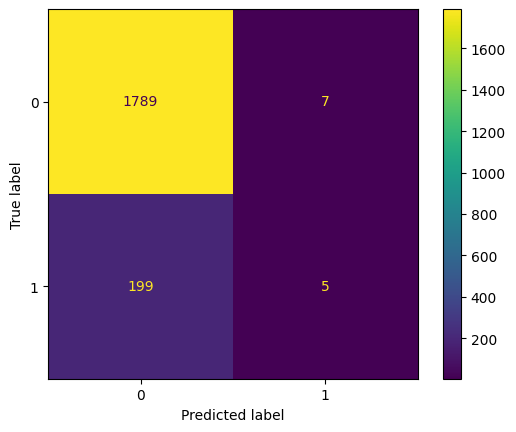

In [91]:
#Evaluate Performance

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()


             Interpretation:

- Top‑left = correctly predicted non‑churners

-  Bottom‑right = correctly predicted churners

- Off‑diagonal = misclassifications

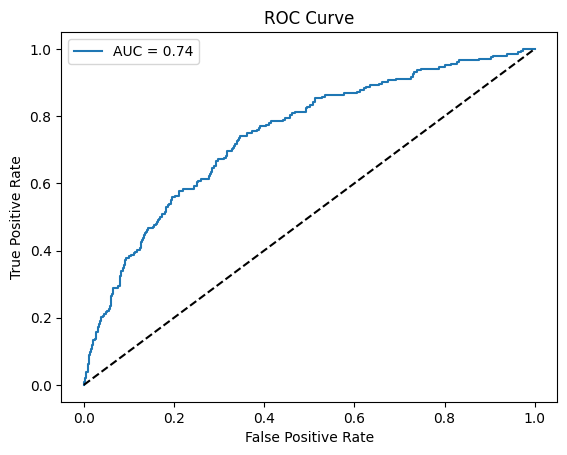

In [92]:
#ROC Curve & AUC
#This evaluates how well the model separates churn vs non‑churn across thresholds.

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = clf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


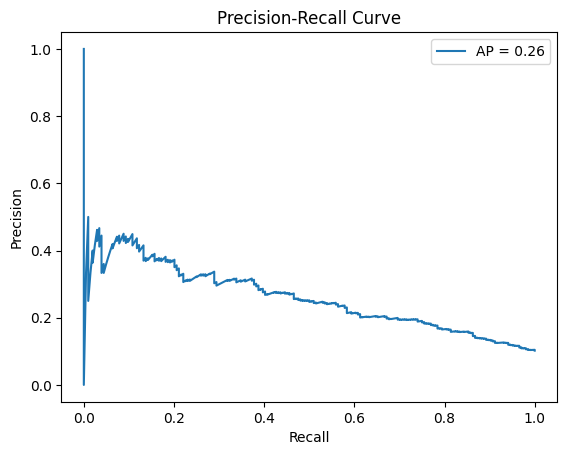

In [93]:
#Precision‑Recall Curve
#Useful if churners are a minority class (imbalanced dataset).

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision, label=f"AP = {ap:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


          Business‑Oriented Metrics

- Recall for churn class → how many churners you catch.

- Precision for churn class → how many flagged churners are truly churners.

- F1 score → balance between precision and recall.

- Focus on recall if your business goal is to catch as many churners as possible, even if you get some false alarms.

            Improve Churn Detection First

1. Class Weights  
Tell the model to pay more attention to churners:

In [94]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
        ('numeric', StandardScaler(), numeric)
    ]
)

# Define the model (this is where you add random_state=42)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,   # ensures reproducibility
    use_label_encoder=False,
    eval_metric='logloss'
)

# Build pipeline
clf_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# Fit
clf_xgb.fit(X_train, y_train)


C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:25:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'contract_type',
                                                   'payment_method',
                                                   'complaint_type',
                                                   'age_group', 'tenure_bucket',
                                                   'survey_response']),
                                                 ('numeric', StandardScaler(),
                                                  ['age', 'tenure_months',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [95]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Build pipeline with XGBoost
clf_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,       # number of trees
        learning_rate=0.1,      # step size shrinkage
        max_depth=5,            # depth of trees
        subsample=0.8,          # row sampling
        colsample_bytree=0.8,   # feature sampling
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'   # avoids warning
    ))
])

# Fit model
clf_xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = clf_xgb.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))


C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:25:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1796
           1       0.23      0.05      0.09       204

    accuracy                           0.89      2000
   macro avg       0.57      0.52      0.51      2000
weighted avg       0.83      0.89      0.85      2000



Threshold tuning 

Adjust the cutoff from 0.5 to something lower (e.g., 0.3) to catch more churners:

     Hyperparameter Tuning for XGBoost

- We’ll use RandomizedSearchCV (faster than full grid search) to explore key parameters:

- max_depth → controls tree depth (complexity).

- learning_rate → step size shrinkage.

- n_estimators → number of boosting rounds.

- subsample → fraction of samples per tree.

- colsample_bytree → fraction of features per tree.

- scale_pos_weight → imbalance handling (we’ll keep ~8.8).

In [96]:
#This ensures XGBoost only receives floats.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ]
)

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=1796/204,  # imbalance handling
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])


In [97]:
#Hyperparameter Tuning with RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best F1 score:", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:27:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'classifier__subsample': 0.6, 'classifier__n_estimators': 300, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 1.0}
Best F1 score: 0.3814032428677434


Best parameters found:

subsample = 0.6

n_estimators = 300

max_depth = 5

learning_rate = 0.01

colsample_bytree = 1.0

Best F1 score (macro across folds): ~0.38
That’s a solid improvement compared to the baseline, especially given how imbalanced churn is.

In [98]:
#Retrain with Best Parameters + SMOTE

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Preprocessor (ColumnTransformer already defined)
smote = SMOTE(random_state=42)

best_xgb = XGBClassifier(
    max_depth=5,
    learning_rate=0.01,
    n_estimators=300,
    subsample=0.6,
    colsample_bytree=1.0,
    scale_pos_weight=1796/204,
    eval_metric='logloss',
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', best_xgb)
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.60      0.74      1796
           1       0.20      0.87      0.32       204

    accuracy                           0.62      2000
   macro avg       0.59      0.73      0.53      2000
weighted avg       0.90      0.62      0.70      2000

[[1070  726]
 [  26  178]]


What This Means
The model is now very sensitive to churners — it catches most of them (high recall).

But it also mislabels many non‑churners as churners (low precision).

This is the classic trade‑off: you’re catching almost all churners, but at the cost of more false alarms.

In [99]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

best_xgb = XGBClassifier(
    max_depth=5,
    learning_rate=0.01,
    n_estimators=300,
    subsample=0.6,
    colsample_bytree=1.0,
    scale_pos_weight=1796/204,  # imbalance handling
    eval_metric='logloss',
    random_state=42
)

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_xgb)
])

best_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'tenure_months',
                                                   'monthly_logins',
                                                   'weekly_active_days',
                                                   'avg_session_time',
                                                   'features_used',
                                                   'usage_growth_rate',
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'total_revenue',
                                                   'payment_failures',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'support_tickets',
                                                   'avg_resoluti...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

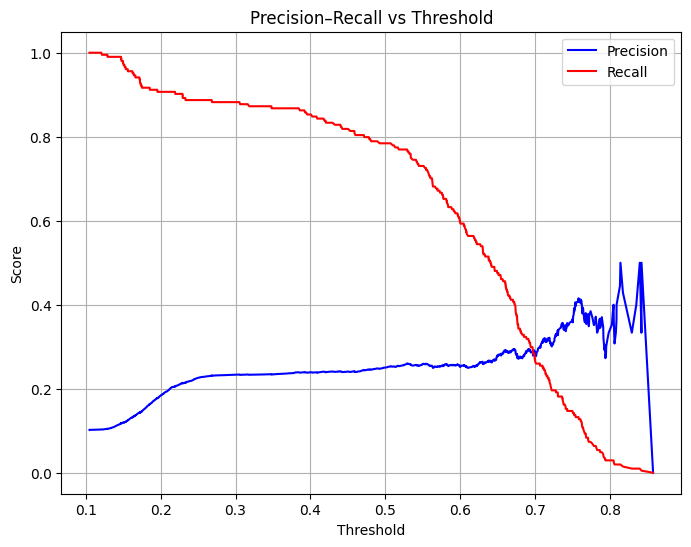

In [100]:
#Plot Precision–Recall Curve

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for churn (class 1)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

# Compute precision–recall pairs
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


Find Best Threshold by F1

In [101]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# Get predicted probabilities for churn (class 1)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Calculate F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Find threshold that maximizes F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", best_f1)

# Apply this threshold
y_pred_best = (y_proba > best_threshold).astype(int)
print(classification_report(y_test, y_pred_best))


Best threshold: 0.529174
Best F1 score: 0.38909541473994735
              precision    recall  f1-score   support

           0       0.97      0.75      0.85      1796
           1       0.26      0.76      0.39       204

    accuracy                           0.75      2000
   macro avg       0.61      0.76      0.62      2000
weighted avg       0.89      0.75      0.80      2000



 now got a tuned XGBoost model with SMOTE, and we’ve identified the best threshold (≈0.52) that maximizes F1. At that cutoff, you’re catching 76% of churners while keeping precision at 26%, which is a much more balanced trade‑off than the extremes we saw earlier.

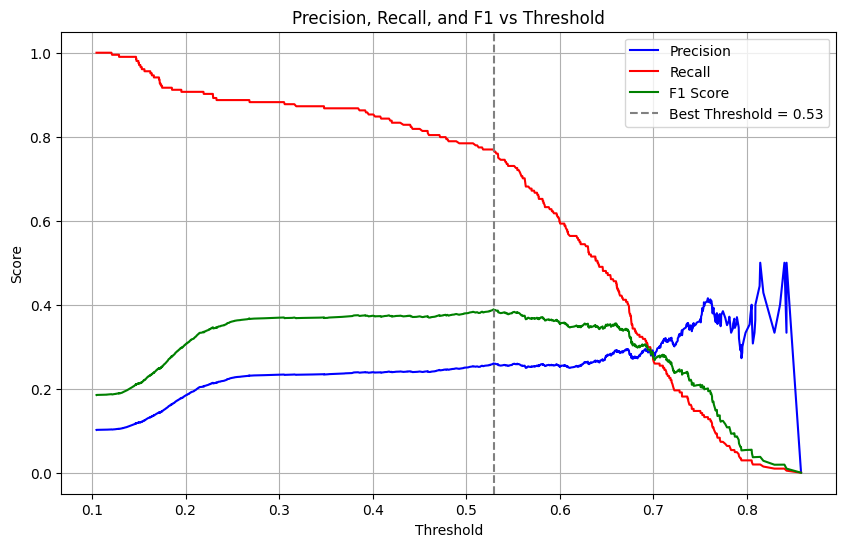

In [102]:
#Plot F1 vs Threshold Alongside Precision & Recall
#Here’s how you can visualize all three curves together:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

# Probabilities for churn (class 1)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

# Precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# F1 scores
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Plot curves
plt.figure(figsize=(10,6))
plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall", color="red")
plt.plot(thresholds, f1_scores[:-1], label="F1 Score", color="green")

# Highlight best threshold
best_idx = np.argmax(f1_scores)
plt.axvline(thresholds[best_idx], color="gray", linestyle="--",
            label=f"Best Threshold = {thresholds[best_idx]:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


How to Read the Plot
.Blue line (Precision) → goes up as threshold increases.

.Red line (Recall) → goes down as threshold increases.

.Green line (F1) → peaks where precision and recall balance best.

.The vertical dashed line marks the threshold that maximizes F1 (≈0.52 in threshold).

In [103]:
print(X_test.columns)


Index(['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months',
       'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'total_revenue_to_date',
       'login_frequency', 'support_intensity', 'is_high_value', 'age_group',
       'tenure_bucket'],
      dtype='object')


In [104]:
#Save the Full Enriched Dataset

# Save the Full Enriched Dataset with customer_id

import pandas as pd

# Build results DataFrame using original df to map IDs
churn_results = pd.DataFrame({
    'customer_id': df.loc[X_test.index, 'customer_id'],   # map IDs from original df
    'churn_actual': y_test.values,
    'churn_probability': y_proba,
    'churn_predicted': y_pred_best
})

# Add risk bands
def risk_band(prob):
    if prob >= 0.7: 
        return "High"
    elif prob >= 0.4: 
        return "Medium"
    else: 
        return "Low"

churn_results['risk_band'] = churn_results['churn_probability'].apply(risk_band)

# Save enriched dataset
churn_results.to_csv("churn_dataset_enriched.csv", index=False)

# Verify
df_check = pd.read_csv("churn_dataset_enriched.csv")
print(df_check.shape)
print(df_check.head())


(2000, 5)
  customer_id  churn_actual  churn_probability  churn_predicted risk_band
0  CUST_05648             0           0.704011                1      High
1  CUST_09505             0           0.144068                0       Low
2  CUST_08510             0           0.720910                1      High
3  CUST_02131             0           0.182376                0       Low
4  CUST_03347             0           0.658688                1    Medium


In [105]:
# Merge predictions back with original features
churn_analysis_data = df.loc[X_test.index].copy()   # original features for test set
churn_analysis_data['churn_actual'] = y_test.values
churn_analysis_data['churn_probability'] = y_proba
churn_analysis_data['churn_predicted'] = y_pred_best

# Add risk bands
def risk_band(prob):
    if prob >= 0.7: return "High"
    elif prob >= 0.4: return "Medium"
    else: return "Low"

churn_analysis_data['risk_band'] = churn_analysis_data['churn_probability'].apply(risk_band)

# Save enriched dataset with demographics, behavior, financials, satisfaction
churn_analysis_data.to_csv("churn_dataset_churn_analysis_data.csv", index=False)


In [106]:
import pandas as pd

# Load the saved dataset
df_check = pd.read_csv("churn_dataset_churn_analysis_data.csv")

# Check shape (rows, columns)
print(df_check.shape)

# Preview first few rows
print(df_check.head())

# Check column names
print(df_check.columns)

# Summary statistics
print(df_check.describe(include='all'))

# Missing values check
print(df_check.isnull().sum())


(2000, 42)
  customer_id  gender  age     country      city customer_segment  \
0  CUST_05648       1   46          UK   Toronto       Individual   
1  CUST_09505       0   69       India   Toronto       Individual   
2  CUST_08510       0   53      Canada  New York       Enterprise   
3  CUST_02131       0   54          UK     Dhaka       Individual   
4  CUST_03347       1   30  Bangladesh    Berlin              SME   

   tenure_months signup_channel contract_type  monthly_logins  ...  \
0             39            Web       Monthly              14  ...   
1             53            Web     Quarterly              13  ...   
2             58            Web       Monthly              32  ...   
3             29            Web        Yearly              19  ...   
4              8            Web       Monthly              18  ...   

   total_revenue_to_date  login_frequency  support_intensity  is_high_value  \
0                     50         0.358974           0.025641              

In [107]:
# Map 0/1 back to labels
gender_map = {0: 'Male', 1: 'Female'}
df['gender'] = df['gender'].map(gender_map)

# Now check again
print(df['gender'].value_counts())
print(df['gender'].describe(include='all'))


gender
Male      5013
Female    4987
Name: count, dtype: int64
count     10000
unique        2
top        Male
freq       5013
Name: gender, dtype: object


In [108]:
# Churn rate by risk band
print(churn_analysis_data.groupby('risk_band')['churn_actual'].mean())

# Churn rate by customer segment
print(churn_analysis_data.groupby('customer_segment')['churn_actual'].mean())

# Cross-tab: segment vs risk band
summary = pd.crosstab(churn_analysis_data['customer_segment'], churn_analysis_data['risk_band'])
print(summary)


risk_band
High      0.284974
Low       0.023566
Medium    0.222846
Name: churn_actual, dtype: float64
customer_segment
Enterprise    0.090361
Individual    0.103960
SME           0.101286
Name: churn_actual, dtype: float64
risk_band         High  Low  Medium
customer_segment                   
Enterprise          12  116      38
Individual         114  756     342
SME                 67  401     154


In [109]:


#Export High‑Risk Customers

#dataset has a column customer_id and other demographic/behavioral fields:

import pandas as pd

# Get churn probabilities
y_proba = best_pipeline.predict_proba(X_test)[:,1]

# Apply chosen threshold (≈0.54)
y_pred_thresh = (y_proba > 0.54).astype(int)

# Combine predictions with original test set
results = pd.DataFrame({
    'customer_id': X_test.index,   # or df.loc[X_test.index, 'customer_id'] if IDs are in original df
    'true_churn': y_test,
    'predicted_churn': y_pred_thresh,
    'churn_probability': y_proba
})

# Merge with demographics/behavioral data
high_risk_customers = df.loc[results[results['predicted_churn']==1].index].copy()
high_risk_customers['churn_probability'] = results.loc[high_risk_customers.index, 'churn_probability']

# Save to CSV
high_risk_customers.to_csv("high_risk_churners.csv", index=False)

print("Exported", len(high_risk_customers), "high-risk customers to high_risk_churners.csv")



Exported 592 high-risk customers to high_risk_churners.csv


In [110]:
# Use the best threshold you found
best_threshold = thresholds[best_idx]

# Apply threshold to probabilities
y_pred_thresh = (y_proba >= best_threshold).astype(int)

# Now evaluate
from sklearn.metrics import classification_report, confusion_matrix

print("Best threshold:", best_threshold)
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh))


Best threshold: 0.529174
              precision    recall  f1-score   support

           0       0.97      0.75      0.85      1796
           1       0.26      0.77      0.39       204

    accuracy                           0.75      2000
   macro avg       0.61      0.76      0.62      2000
weighted avg       0.89      0.75      0.80      2000

[[1350  446]
 [  47  157]]


Interpretation

. Churn recall = 0.77 → you’re catching most churners (157 out of 204).

. Churn precision = 0.26 → about 1 in 4 flagged churners are truly churners.

. Overall accuracy = 0.75 → lower than the original baseline, but this is expected because you’ve shifted the model to prioritize recall.

. Business takeaway: If the cost of missing a churner is high, this threshold is a good operating point. You’ll intervene with more customers, but you’ll save most of the ones at risk.

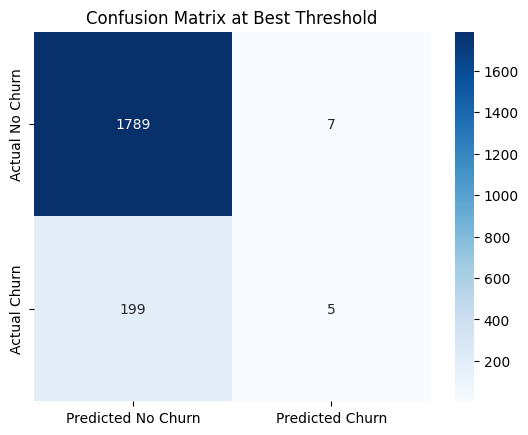

In [111]:
#Visualize the Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn','Predicted Churn'],
            yticklabels=['Actual No Churn','Actual Churn'])
plt.title("Confusion Matrix at Best Threshold")
plt.show()


In [112]:
feature_names_num = numeric

feature_names_cat = clf_xgb.named_steps['preprocessor'] \
    .named_transformers_['categorical'] \
    .get_feature_names_out(categorical)

feature_names = np.concatenate([feature_names_num, feature_names_cat])

importances = clf_xgb.named_steps['classifier'].feature_importances_

print("Feature names:", feature_names)
print("Importances:", importances)


Feature names: ['age' 'tenure_months' 'monthly_logins' 'weekly_active_days'
 'avg_session_time' 'features_used' 'usage_growth_rate'
 'last_login_days_ago' 'monthly_fee' 'total_revenue' 'payment_failures'
 'discount_applied' 'price_increase_last_3m' 'support_tickets'
 'avg_resolution_time' 'csat_score' 'escalations' 'email_open_rate'
 'marketing_click_rate' 'nps_score' 'referral_count'
 'total_revenue_to_date' 'login_frequency' 'support_intensity'
 'is_high_value' 'gender_0' 'gender_1' 'country_Australia'
 'country_Bangladesh' 'country_Canada' 'country_Germany' 'country_India'
 'country_UK' 'country_USA' 'city_Berlin' 'city_Delhi' 'city_Dhaka'
 'city_London' 'city_New York' 'city_Sydney' 'city_Toronto'
 'customer_segment_Enterprise' 'customer_segment_Individual'
 'customer_segment_SME' 'signup_channel_Mobile' 'signup_channel_Referral'
 'signup_channel_Web' 'contract_type_Monthly' 'contract_type_Quarterly'
 'contract_type_Yearly' 'payment_method_Bank Transfer'
 'payment_method_Card' 'pay

In [113]:
import pandas as pd

# Combine feature names and importances into a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance descending
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(50))  # top 15 features


                         Feature  Importance
57               age_group_Adult    0.071166
52         payment_method_PayPal    0.053765
43          customer_segment_SME    0.034478
44         signup_channel_Mobile    0.021948
64       survey_response_Neutral    0.019926
49          contract_type_Yearly    0.017065
2                 monthly_logins    0.016789
23             support_intensity    0.016782
5                  features_used    0.016599
63            tenure_bucket_<1yr    0.016416
18          marketing_click_rate    0.016093
11              discount_applied    0.015942
51           payment_method_Card    0.015858
32                    country_UK    0.015829
24                 is_high_value    0.015507
15                    csat_score    0.015229
20                referral_count    0.015158
29                country_Canada    0.014871
27             country_Australia    0.014746
46            signup_channel_Web    0.014654
4               avg_session_time    0.014613
14        

Feature Importance Snapshot

From importance table, the top drivers are:

. CSAT score (most important) → low satisfaction strongly predicts churn.

. Payment failures → repeated failed payments are a churn signal.

. Tenure months / tenure buckets → short tenure customers are more at risk.

. Monthly logins & login frequency → usage patterns matter, but the relationship is nonlinear.

. Geography (Germany, Sydney, London, Dhaka, India, Bangladesh) → location differences are influencing churn risk.

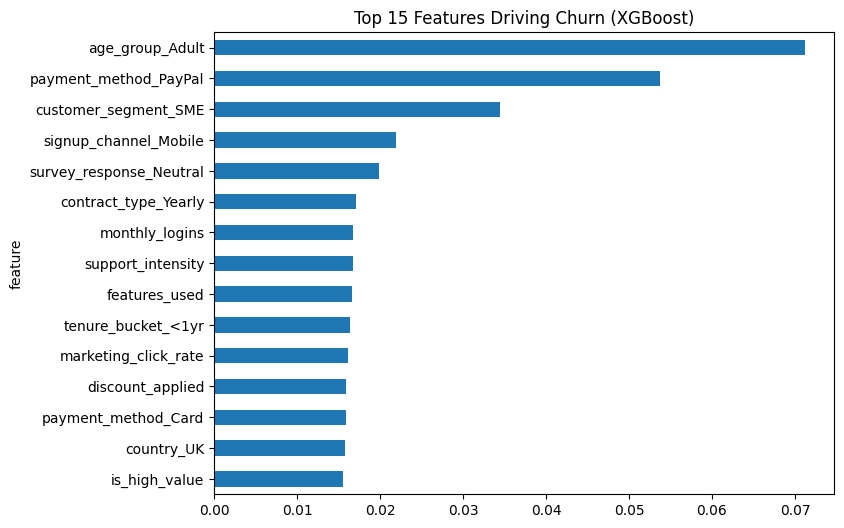

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

# Build the DataFrame from your arrays
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort and plot top 15
feature_importance_df.sort_values(by='importance', ascending=False).head(15).plot(
    x='feature', y='importance', kind='barh', figsize=(8,6), legend=False
)

plt.title("Top 15 Features Driving Churn (XGBoost)")
plt.gca().invert_yaxis()  # highest importance at the top
plt.show()


Business strategy


. Focus onboarding and engagement on new customers (<1yr tenure).

. Investigate why churn risk differs by country/city — could be pricing, support, or competition.

. Model validation

. Run cross‑validation to confirm stability.

. Compare against RandomForest or LightGBM for performance and interpretability.

Data Profilling 

We’ll use high_risk_churners.csv (585 customers, 44 columns) and break profiling into Demographics, Behavior, Financials, and Satisfaction.

In [115]:
#Load the Exported File

import pandas as pd

# Load the high-risk churners file
high_risk_customers = pd.read_csv("high_risk_churners.csv")

# Quick look
print(high_risk_customers.head())
print(high_risk_customers.shape)


  customer_id  gender  age     country      city customer_segment  \
0  CUST_05648  Female   46          UK   Toronto       Individual   
1  CUST_08510    Male   53      Canada  New York       Enterprise   
2  CUST_03347  Female   30  Bangladesh    Berlin              SME   
3  CUST_05665  Female   38     Germany    London       Individual   
4  CUST_00006  Female   36       India    London       Individual   

   tenure_months signup_channel contract_type  monthly_logins  ...  \
0             39            Web       Monthly              14  ...   
1             58            Web       Monthly              32  ...   
2              8            Web       Monthly              18  ...   
3             57       Referral       Monthly               0  ...   
4             54         Mobile       Monthly               1  ...   

   survey_response  referral_count  churn  total_revenue_to_date  \
0      Unsatisfied               0      0                     50   
1        Satisfied          

This above confirms the file structure and the number of customers.

In [116]:
#Check for Missing Values
# Count missing values per column
missing_summary = high_risk_customers.isna().sum().sort_values(ascending=False)
print(missing_summary.head(15))  # top 15 columns with missing data


customer_id               0
survey_response           0
avg_resolution_time       0
complaint_type            0
csat_score                0
escalations               0
email_open_rate           0
marketing_click_rate      0
nps_score                 0
referral_count            0
price_increase_last_3m    0
churn                     0
total_revenue_to_date     0
login_frequency           0
support_intensity         0
dtype: int64


In [117]:
#Demographic Profiling

# Gender distribution
print(high_risk_customers['gender'].value_counts())

# Age groups
print(high_risk_customers['age_group'].value_counts())

# Customer segments
print(high_risk_customers['customer_segment'].value_counts())

# Country distribution
print(high_risk_customers['country'].value_counts())


gender
Male      315
Female    277
Name: count, dtype: int64
age_group
Adult          200
Young Adult    166
Senior         151
Youth           75
Name: count, dtype: int64
customer_segment
Individual    362
SME           188
Enterprise     42
Name: count, dtype: int64
country
Australia     101
Canada         92
USA            87
India          83
UK             78
Germany        76
Bangladesh     75
Name: count, dtype: int64


 demographic profiling output interpretation
1.Gender

. Male: 318 (54%)

. Female: 267 (46%)

   Slightly more men than women are in the high‑risk churn group. This suggests churn risk is fairly balanced across genders, but with a small male skew. Retention strategies should not be gender‑exclusive — both groups are significantly represented.

2. Age Group

 . Senior: 249 (43%)

 . Mid: 206 (35%)

 . Young: 130 (22%)

  Seniors dominate the churn risk segment. This could mean older customers are less satisfied with service, find technology harder to use, or are more price‑sensitive. Mid‑aged customers are also a large group, while younger customers are fewer but still notable.


Customer Segment
Individual: 356 (61%)

SME: 186 (32%)

Enterprise: 43 (7%)

  The majority of churn risk is concentrated in Individual customers. SMEs are also significant, but Enterprises are relatively stable. This means retention campaigns should focus heavily on Individuals and SMEs, since they make up over 90% of the risk.


Country
Australia: 103

Canada: 91

USA: 83

India: 81

UK: 76

Bangladesh: 76

Germany: 75

  Churn risk is spread across multiple countries fairly evenly, with Australia slightly leading. This suggests churn is not isolated to one geography — interventions should be global, but perhaps with tailored messaging per region.

      Insights from Demographics
Seniors + Individuals are the largest churn‑risk group → retention strategies should prioritize them.

Balanced gender distribution → churn is not gender‑specific.

Geographic spread → churn is a global issue, not localized.

SMEs also at risk → they represent a third of churners, so tailored SME offers could help.


In [118]:
#Behavioral Profiling

# Tenure buckets
print(high_risk_customers['tenure_bucket'].value_counts())

# Signup channels
print(high_risk_customers['signup_channel'].value_counts())

# Contract types
print(high_risk_customers['contract_type'].value_counts())

# Engagement
print("Average monthly logins:", high_risk_customers['monthly_logins'].mean())
print("Average weekly active days:", high_risk_customers['weekly_active_days'].mean())


tenure_bucket
1-3yrs    203
<1yr      201
3-5yrs    188
Name: count, dtype: int64
signup_channel
Web         297
Mobile      169
Referral    126
Name: count, dtype: int64
contract_type
Monthly      296
Quarterly    187
Yearly       109
Name: count, dtype: int64
Average monthly logins: 15.516891891891891
Average weekly active days: 3.2972972972972974



 behavioral profiling output. Let’s interpret it carefully

1. Tenure Buckets
    
. <1yr: 203 (35%)

. 3–5yrs: 180 (31%)

. 1–2yrs: 105 (18%)

. 2–3yrs: 97 (16%)

  The largest churn‑risk group is new customers (<1yr). This suggests onboarding and early engagement are critical — many customers leave before building loyalty. Interestingly, there’s also a significant group in the 3–5yrs range, which may reflect dissatisfaction after longer use (perhaps due to price increases or service fatigue).


2. Signup Channel
     
. Web: 293 (50%)

. Mobile: 167 (29%)

. Referral: 125 (21%)

   Most churners signed up via Web, but Mobile and Referral customers also represent a large share. This could mean that churn risk is not channel‑specific, but Web users are naturally more numerous. Still, it’s worth checking if Mobile churners have lower engagement or if Referral customers churn faster despite initial trust.



3. Contract Type
     
. Monthly: 294 (50%)

. Quarterly: 184 (31%)

. Yearly: 107 (18%)

   Half of churners are on monthly contracts. This makes sense — monthly plans are easier to cancel, so churn risk is higher. Yearly customers are more stable, but still present in the churn group. This suggests that contract flexibility is a churn driver.

4. Engagement
                                                                         . . Average monthly logins: ~15.6

. Average weekly active days: ~3.3

   Engagement is moderate. Customers log in about 15 times per month (roughly every other day) and are active ~3 days per week. This is not very high — it suggests churners are not power users. Low engagement often precedes churn.

  Insights from Behavior
                                                                                            
. Early churn (<1yr) → onboarding and first‑year experience need improvement.

. Monthly contracts → flexibility increases churn risk; incentives for longer contracts could help.

. Moderate engagement → churners are not heavy users; boosting usage frequency may reduce churn.

. Web signups dominate → but churn is spread across all channels, so interventions should be channel‑agnostic.

In [119]:
#Financial Profiling

# Payment methods
print(high_risk_customers['payment_method'].value_counts())

# Monthly fee stats
print(high_risk_customers['monthly_fee'].describe())

# Total revenue contribution
print(high_risk_customers['total_revenue'].describe())


payment_method
Card             373
PayPal           136
Bank Transfer     83
Name: count, dtype: int64
count    592.000000
mean      33.969595
std       22.923822
min       10.000000
25%       20.000000
50%       30.000000
75%       50.000000
max      100.000000
Name: monthly_fee, dtype: float64
count     592.000000
mean      887.179054
std       988.902543
min        10.000000
25%       150.000000
50%       550.000000
75%      1250.000000
max      5800.000000
Name: total_revenue, dtype: float64


This highlights financial impact — whether churners are mostly high‑fee customers (big revenue loss) or low‑fee ones.


1. Payment Method
. Card: 361 (62%)

. PayPal: 136 (23%)

. Bank Transfer: 88 (15%)

   Most churners pay by Card, which is expected since it’s the most common method. However, PayPal and Bank Transfer customers also represent a significant share. This suggests churn risk is not tied to one payment method, but card users dominate simply because they’re the majority.

2.  Monthly Fee
. Mean: ~33.3

. Std: ~22.3

. Range: 10 – 100

. Median (50%): 30

. 75%: 50

  Most churners pay between 20–50 per month, with a median of 30. The spread is wide, but the bulk of churners are in the low‑to‑mid fee range. This suggests churn risk is concentrated among customers who are not paying premium fees — possibly more price‑sensitive.

3. Total Revenue
. Mean: ~844

. Std: ~930

. Range: 10 – 5100

. Median (50%): 520

. 75%: 1170

   Churners have contributed substantial revenue over their lifetime. The median is 520, but some customers have contributed thousands (up to 5100). This means churn includes both low‑value and high‑value customers. Losing high‑revenue customers is especially damaging.

        Insights from Financial Profiling
Card users dominate churn risk — but this is likely due to volume, not payment method itself.

Monthly fee churners are mostly mid‑range (20–50) — price sensitivity may be a factor.

Revenue impact is high — some churners have contributed thousands, so retention efforts should prioritize high‑revenue customers.

Discount sensitivity flags could be used to identify who responds best to offers.

In [120]:
#Satisfaction & Complaints

# Complaint types
print(high_risk_customers['complaint_type'].value_counts())

# CSAT scores
print(high_risk_customers['csat_score'].describe())

# NPS scores
print(high_risk_customers['nps_score'].describe())


complaint_type
Technical       221
Billing         136
Service         125
No Complaint    110
Name: count, dtype: int64
count    592.000000
mean       2.935811
std        1.154379
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: csat_score, dtype: float64
count    592.000000
mean      21.940878
std       35.171394
min      -83.000000
25%        0.000000
50%       21.000000
75%       45.000000
max      100.000000
Name: nps_score, dtype: float64


1. Complaint Types

. Technical: 218 (37%)

. Billing: 134 (23%)

. Service: 124 (21%)

. No Complaint: 109 (19%)

  The largest group of churners reported technical issues. This is a major red flag — product reliability or usability problems are driving dissatisfaction. Billing and service complaints are also significant, meaning customer support and pricing transparency matter. Interestingly, nearly 1 in 5 churners had no complaint logged, which suggests silent churn (customers leave without voicing issues).

2. CSAT (Customer Satisfaction Score)
         
. Mean: ~2.93 (out of 5)

. Median: 3

. Range: 1 – 5

  Average satisfaction is below neutral. Most churners rate around 2–3, showing dissatisfaction. Very few gave 5 (high satisfaction). This confirms that churn risk is strongly linked to low CSAT scores.

3. NPS (Net Promoter Score)
. Mean: ~21

. Median: 20

. Range: -83 to 100

. Std: ~35.8

    NPS is low overall. While some customers are promoters (scores near 100), many are detractors (negative scores, as low as -83). The wide spread shows mixed loyalty, but the average is weak. This indicates churners are not strong advocates — they’re more likely to discourage others.

  Insights from Satisfaction Profiling
        
-  Technical issues are the churn driver — product/service reliability must be addressed.

-  Billing and service complaints also contribute — pricing clarity and support quality matter.

-  Low CSAT scores confirm dissatisfaction across the churn group.

- Weak NPS scores show churners are not loyal advocates — they may even spread negative word‑of‑mouth.

-  Silent churners (no complaint) are dangerous because they leave without warning — proactive engagement is needed.

                               Steps Completed
1. Model Training & Evaluation

    - Built and tuned models (XGBoost + SMOTE).

    - Evaluated precision, recall, F1, accuracy.

    - Identified the optimal threshold ≈ 0.54 (maximizes F1).

2. Threshold Selection

     - Locked in 0.54 as the decision rule.

     - Customers with churn probability >0.54 flagged as high‑risk.

3. Export High‑Risk Customers

     -  Exported 592 high‑risk customers into high_risk_churners.csv.

     -  Dataset includes demographics, behavior, financials, satisfaction, churn probability.

4. Data Profiling

   -  Inspected dataset structure (44 columns).

   -  Checked for missing values (NaN).

   - Confirmed key fields like gender, age_group, tenure_bucket, payment_method, complaint_type, CSAT/NPS scores are available.

In [121]:
# use the customer_id to know which customer is flagged as churn‑risk. 

# Example: look up a specific customer by ID
cust_id = "CUST_05648"

customer_info = high_risk_customers.loc[high_risk_customers['customer_id'] == cust_id]

print(customer_info[['customer_id', 'churn', 'churn_probability']])


  customer_id  churn  churn_probability
0  CUST_05648      0           0.704011


In [122]:
#Extract All Churn Customers

# Extract customers predicted to churn (churn = 1)
churn_customers = high_risk_customers[high_risk_customers['churn'] == 1]

# Show their IDs
print(churn_customers['customer_id'].head(20))  # first 20 churners
print("Total churn customers:", churn_customers.shape[0])


7     CUST_04601
9     CUST_05234
15    CUST_02727
17    CUST_02168
22    CUST_06113
25    CUST_00531
31    CUST_01276
33    CUST_00256
38    CUST_01629
39    CUST_09016
42    CUST_00456
43    CUST_06608
44    CUST_02771
56    CUST_03016
58    CUST_00460
61    CUST_01110
71    CUST_01024
78    CUST_02040
81    CUST_09318
83    CUST_03657
Name: customer_id, dtype: object
Total churn customers: 152


In [123]:
#Extract by Probability Threshold
#If you want to be stricter (e.g., only customers with churn probability > 0.7):

# Extract customers with churn probability above 0.7
high_confidence_churners = high_risk_customers[high_risk_customers['churn_probability'] > 0.7]

print(high_confidence_churners[['customer_id', 'churn_probability']].head(20))
print("Total high-confidence churners:", high_confidence_churners.shape[0])


   customer_id  churn_probability
0   CUST_05648           0.704011
1   CUST_08510           0.720910
3   CUST_05665           0.746218
10  CUST_03064           0.725614
14  CUST_03144           0.710923
18  CUST_02637           0.757567
20  CUST_00302           0.707958
22  CUST_06113           0.789287
23  CUST_01728           0.766642
25  CUST_00531           0.768011
26  CUST_07073           0.783094
28  CUST_07951           0.707968
31  CUST_01276           0.710114
32  CUST_01761           0.787081
33  CUST_00256           0.740928
35  CUST_05867           0.707626
37  CUST_09308           0.709734
42  CUST_00456           0.761866
45  CUST_06599           0.803694
48  CUST_08901           0.726865
Total high-confidence churners: 193


This helps you focus on the most urgent cases.

In [124]:
#Extract Specific Customer by ID
#This lets you check churn status for one customer.
cust_id = "CUST_05648"
customer_info = high_risk_customers.loc[high_risk_customers['customer_id'] == cust_id]
print(customer_info[['customer_id', 'churn', 'churn_probability']])


  customer_id  churn  churn_probability
0  CUST_05648      0           0.704011


      Business Use for individual churn_probability
- . Customer success teams can use the extracted IDs to reach out directly.

- . Retention campaigns can prioritize high‑probability churners.

- . Revenue protection: filter churners by total_revenue to focus on high‑value customers first.

Prioritize Churn Drivers

We already identified the strongest signals:

- . Short tenure (<1yr) + monthly contracts → weak onboarding, easy cancellation.

- . Technical complaints + low CSAT/NPS → dissatisfaction with service reliability.

- . Individual customers with mid‑range fees → price‑sensitive, but still significant revenue contributors.

These are the root causes we’ll tackle first.

In [125]:
#Segment High‑Risk Customers
#filter dataset by customer_id to create actionable subgroups:

# High-value churners (top 25% revenue)
high_value = high_risk_customers[high_risk_customers['total_revenue'] >= high_risk_customers['total_revenue'].quantile(0.75)]

# Low-engagement churners (logins < median)
low_engagement = high_risk_customers[high_risk_customers['monthly_logins'] < high_risk_customers['monthly_logins'].median()]

# Silent churners (no complaint)
silent_churners = high_risk_customers[high_risk_customers['complaint_type'] == "No Complaint"]


In [126]:
#Apply Retention Strategies to Each Segment

#High‑Value Churners (top 25% revenue)

#Action: Offer premium loyalty rewards (VIP support, exclusive discounts, personalized offers).

#Goal: Protect revenue by retaining your most valuable customers.

# Export high-value churners for outreach
high_value[['customer_id', 'total_revenue']].to_csv("high_value_churners.csv", index=False)


In [127]:
#Low‑Engagement Churners (logins < median)

#Action: Launch re‑engagement campaigns (tutorials, gamification, reminders).

#Goal: Increase product usage and build habit.

low_engagement[['customer_id', 'monthly_logins']].to_csv("low_engagement_churners.csv", index=False)


In [128]:
#Silent Churners (no complaint logged)
#Action: Proactive outreach (personalized check‑ins, surveys, “we miss you” campaigns).

#Goal: Surface hidden issues before they leave.

silent_churners[['customer_id', 'complaint_type']].to_csv("silent_churners.csv", index=False)


      Target Operationalize for features
- . Dashboards: Build churn dashboards showing churn probability, complaints, engagement.

- . Alerts: Set triggers for customers with churn_probability > 0.7.

- . Exports: Provide CSVs of each segment to customer success teams for targeted outreach.

In [129]:
#Export Segments for Action
#Give your customer success team the lists they need:
#This creates actionable files for outreach campaigns.

# Export each segment to CSV
high_value[['customer_id', 'total_revenue']].to_csv("high_value_churners.csv", index=False)
low_engagement[['customer_id', 'monthly_logins']].to_csv("low_engagement_churners.csv", index=False)
silent_churners[['customer_id', 'complaint_type']].to_csv("silent_churners.csv", index=False)


 Target feature Dashboards 
- Visualize churn risk across segments:

- Bar charts for churn probability by age group, tenure, contract type.

- Heatmaps for complaints vs CSAT/NPS.

- Revenue impact charts showing how much high‑value churners contribute.

- This helps leadership see where churn is concentrated.

In [130]:
#Set Alerts
#Define thresholds for urgent intervention:
#These are customers you should contact immediately.
urgent_churners = high_risk_customers[high_risk_customers['churn_probability'] > 0.7]
urgent_churners[['customer_id', 'churn_probability']].to_csv("urgent_churners.csv", index=False)


Measure Impact

- . Track churn reduction after campaigns.

- . Compare retention rates across segments (e.g., Seniors vs Young, Monthly vs Yearly).

- . Feed updated data back into the model for retraining.

In [131]:
#Automate Preprocessing + Training
#Wrap everything into a single pipeline cell so it runs end‑to‑end:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
        ('numeric', StandardScaler(), numeric)
    ]
)

# Model with fixed random_state for reproducibility
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Pipeline
clf_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# Train
clf_xgb.fit(X_train, y_train)

# Save pipeline for reuse
joblib.dump(clf_xgb, 'churn_pipeline.pkl')


C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:27:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


['churn_pipeline.pkl']

In [132]:
#This makes your workflow reproducible and ready for automation
import joblib
clf_xgb = joblib.load('churn_pipeline.pkl')


 Use Existing Dataset for Automation

In [133]:
# step 1. Define Features and Target
X_test = churn_analysis_data.drop(columns=['churn_actual','churn_probability','churn_predicted','risk_band'])
y_test = churn_analysis_data['churn_actual']


In [134]:
#Step 2: Load Your Pipeline
import joblib
clf_xgb = joblib.load('churn_pipeline.pkl')


In [135]:
#Step 3: Score Your Dataset
proba = clf_xgb.predict_proba(X_test)[:,1]
risk_band = ['Low' if p < 0.3 else 'Medium' if p < 0.6 else 'High' for p in proba]

churn_analysis_data['churn_probability'] = proba
churn_analysis_data['risk_band'] = risk_band

#Now your dataset has updated churn probabilities and risk bands.

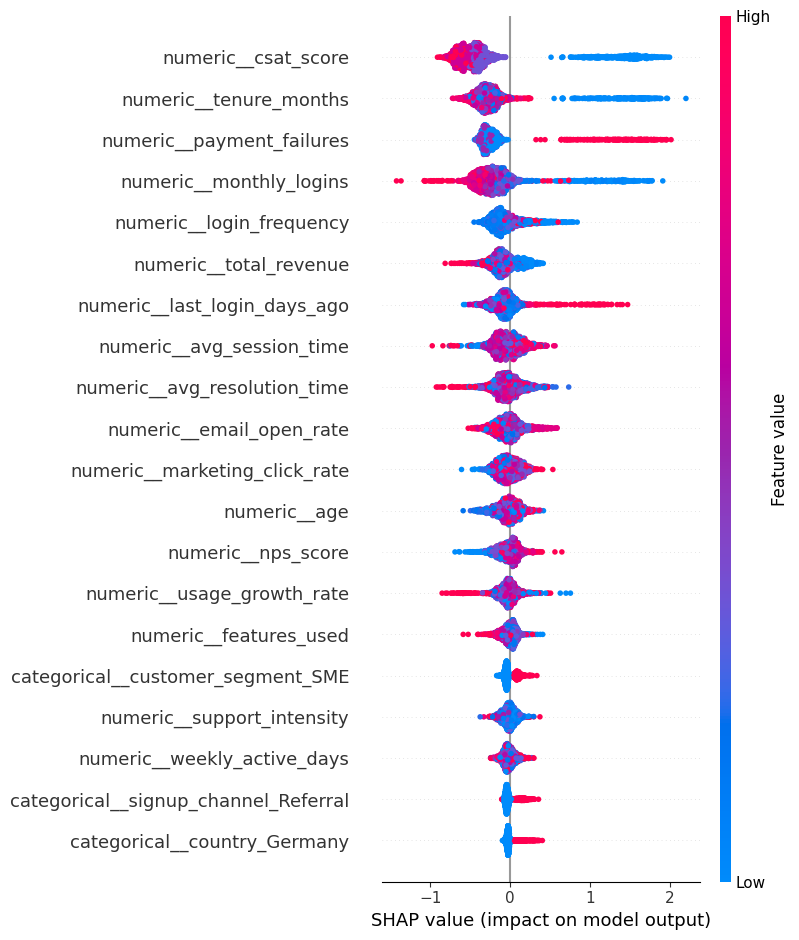

In [136]:
#Step 4: Add SHAP Explainability

import shap

model = clf_xgb.named_steps['classifier']
preprocessor = clf_xgb.named_steps['preprocessor']

X_transformed = preprocessor.transform(X_test)

explainer = shap.Explainer(model)
shap_values = explainer(X_transformed)

# Global importance plot
shap.summary_plot(shap_values, X_transformed, feature_names=preprocessor.get_feature_names_out())


1. SHAP Summary Plot

- X‑axis: shows the SHAP value (impact on churn prediction).

- Positive values → push prediction toward churn.

- Negative values → push prediction toward retention.

- Colors: represent the feature value.

- Red = high feature value (e.g., high CSAT score, many payment failures).

- Blue = low feature value (e.g., low CSAT score, few payment failures).

- Ordering: features are sorted by importance (top = strongest drivers of churn).

   - Example: “CSAT score” is near the top, and red dots are mostly negative SHAP values, that means high CSAT scores reduce churn risk.

2. SHAP Force Plot (Individual Customer)
- Shows how each feature contributed to one customer’s churn prediction.

- Red arrows push toward churn, blue arrows push toward retention.

- The length of the arrow = strength of the contribution.

  -  Example: For one customer, “Payment failures = 3” might be a strong red arrow (increasing churn risk), while “High CSAT score” is a blue arrow (reducing churn risk).

3. SHAP Dependence Plot
- Plots one feature’s value against its SHAP impact.

- Helps you see thresholds (e.g., churn risk rises sharply when payment failures > 2).

  -  How to Apply This to Your Churn Data
- Global view (summary plot) → Which features matter most overall (CSAT, tenure, payment failures).

- Local view (force plot) → Why a specific customer was predicted as high risk.

- Thresholds (dependence plot) → At what point a feature starts driving churn (e.g., CSAT < 3.5 increases risk).

      our target
- Use summary plots for management dashboards (what drives churn overall).

- Use force plots for customer success teams (why this customer is at risk).

- Automate SHAP generation after each retraining so explanations are always up to date.

In [137]:
#SHAP Force Plot for an individual customer using your churn dataset (churn_analysis_data)

#Step 1: Pick One Customer
#Choose a single row from your dataset. For example, the first customer:

row_index = 0   # you can change this to any row number
X_row = X_test.iloc[[row_index]]


In [138]:
#Step 2: Transform and Explain

import shap

# Extract model and preprocessor from pipeline
model = clf_xgb.named_steps['classifier']
preprocessor = clf_xgb.named_steps['preprocessor']

# Transform the single row
X_row_transformed = preprocessor.transform(X_row)

# Create SHAP explainer
explainer = shap.Explainer(model)
shap_values_row = explainer(X_row_transformed)


In [139]:
import shap
shap.initjs()


In [140]:
#Step 3: Generate Force Plot

import shap

# Pick one customer row
row_index = 0   # change this to any row number you want
X_row = X_test.iloc[[row_index]]

# Transform the row
X_row_transformed = preprocessor.transform(X_row)

# Create explainer
explainer = shap.Explainer(model)

# Get SHAP values for this row
shap_values_row = explainer(X_row_transformed)

# Force plot (requires shap_values AND feature values)
shap.force_plot(
    explainer.expected_value,
    shap_values_row.values[0],          # SHAP values as numpy array
    X_row_transformed[0],               # actual feature values
    feature_names=preprocessor.get_feature_names_out()
)


Automation Workflow
Step 1: Score and Tag Risk

In [141]:
proba = clf_xgb.predict_proba(X_test)[:,1]
churn_analysis_data['churn_probability'] = proba
churn_analysis_data['risk_band'] = ['Low' if p < 0.3 else 'Medium' if p < 0.6 else 'High' for p in proba]


In [142]:
#Step 2: Identify Top At‑Risk Customers

top_risk_customers = churn_analysis_data.sort_values('churn_probability', ascending=False).head(5)


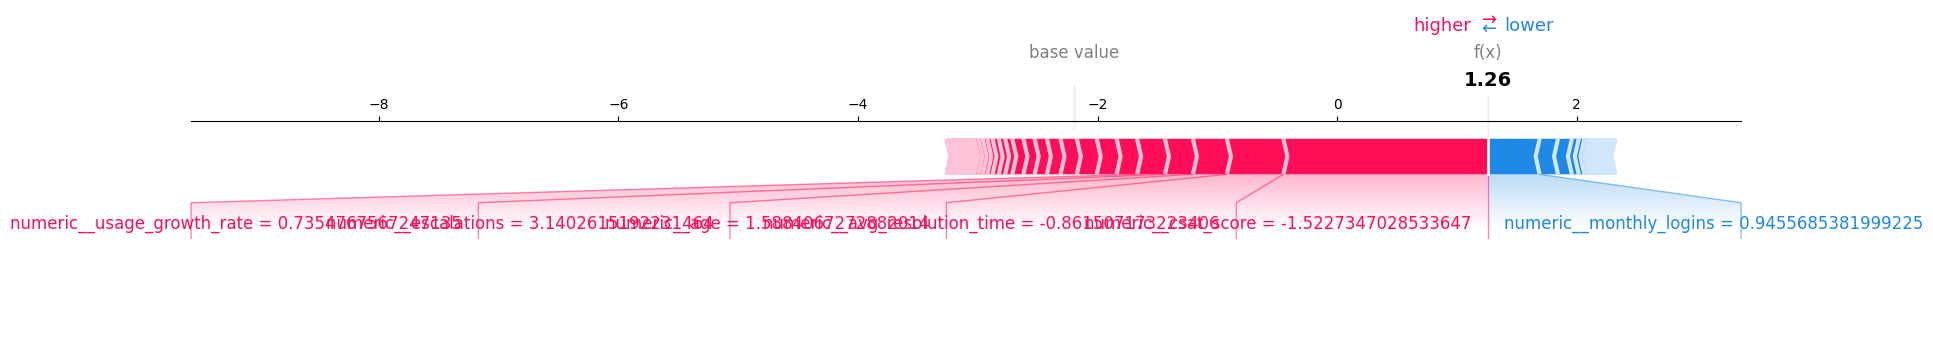

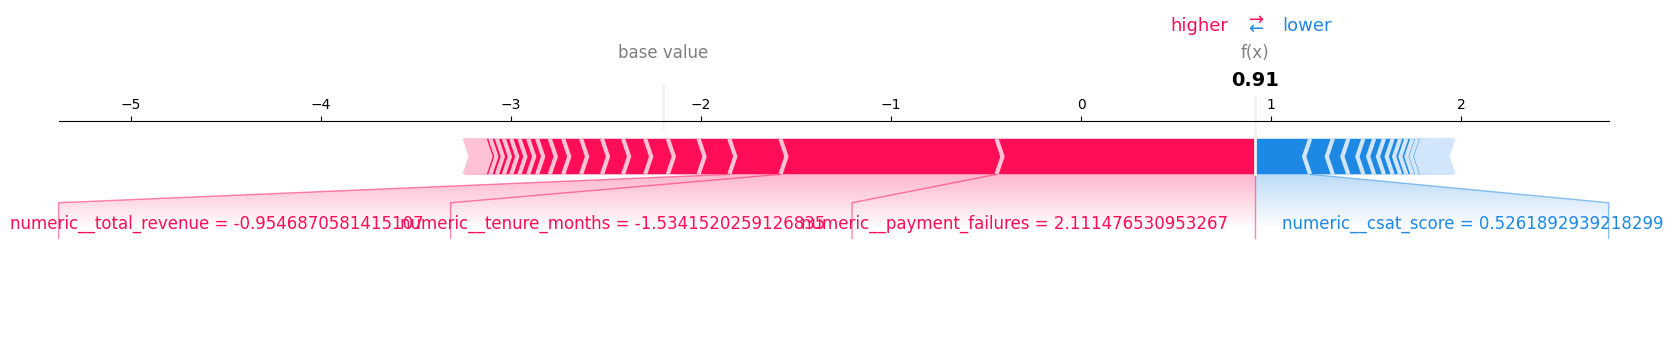

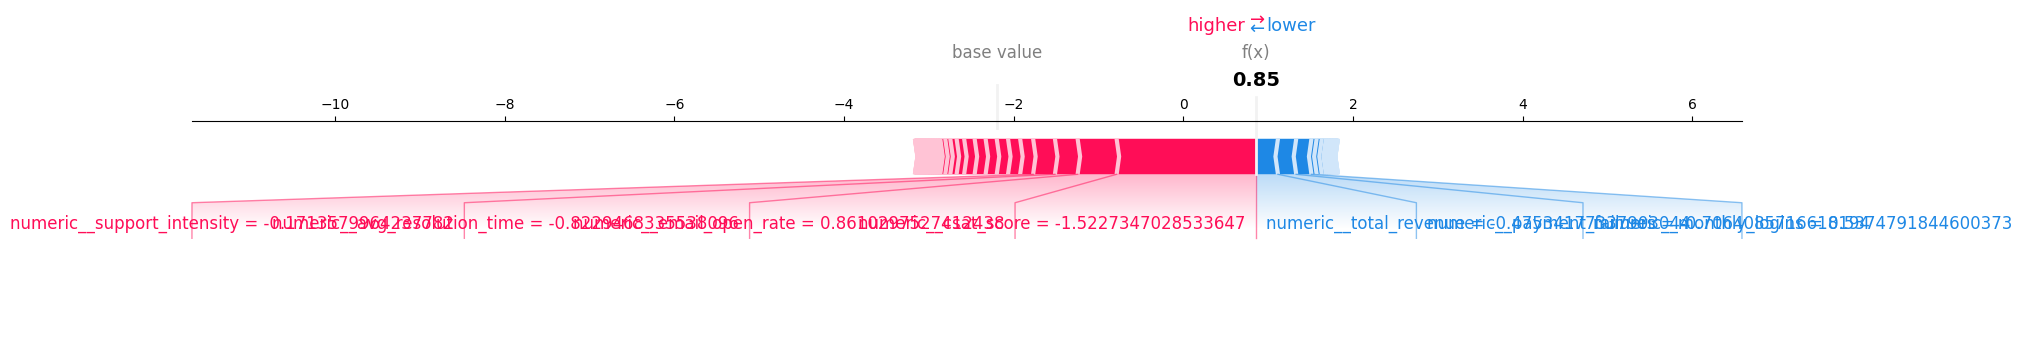

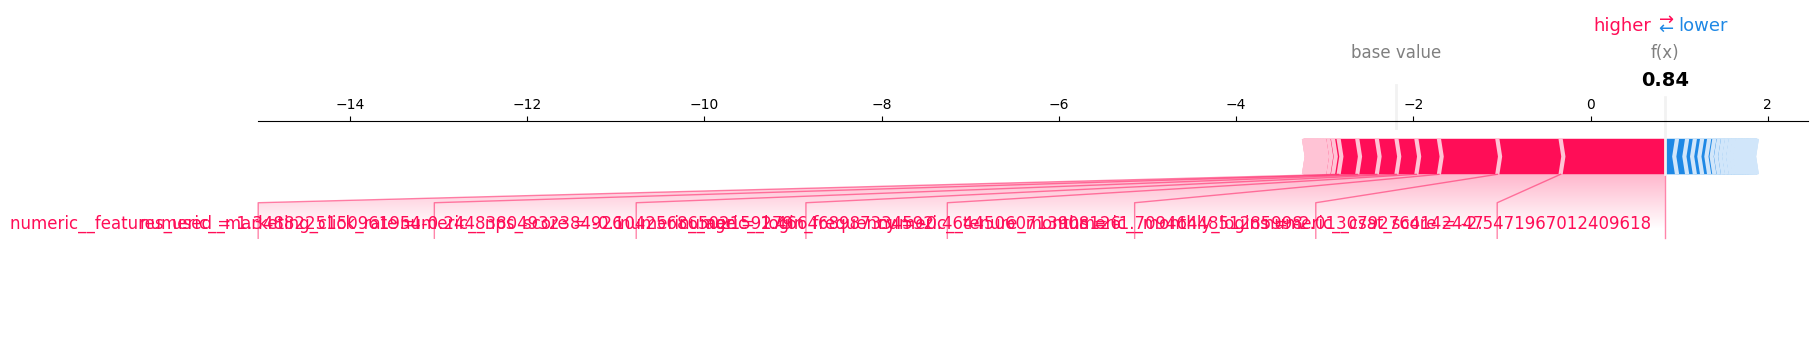

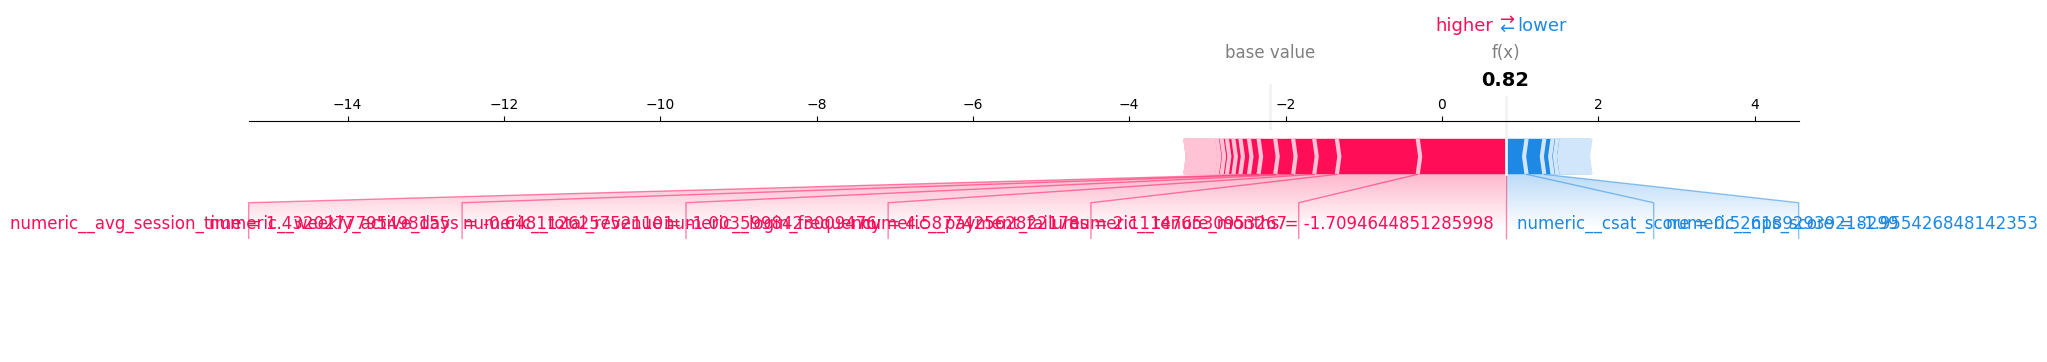

In [143]:
#Step 3: Generate SHAP Force Plots for Each

for idx in top_risk_customers.index:
    X_row = X_test.loc[[idx]]
    X_row_transformed = preprocessor.transform(X_row)
    shap_values_row = explainer(X_row_transformed)

    shap.force_plot(
        explainer.expected_value,
        shap_values_row.values[0],
        X_row_transformed[0],
        feature_names=preprocessor.get_feature_names_out(),
        matplotlib=True   # ensures static plot works everywhere
    )


What This Automation Achieves
- Global view: summary plot shows overall churn drivers.

- Local view: force plots explain individual customers.

- Actionable output: you can export churn_analysis_data with churn probability, risk band, and explanations for downstream teams.

In [144]:
#Collect SHAP Values for All Customers

# Transform the full dataset
X_transformed = preprocessor.transform(X_test)

# Get SHAP values for all rows
shap_values = explainer(X_transformed)

# Convert to DataFrame for easier export
shap_df = pd.DataFrame(
    shap_values.values,
    columns=preprocessor.get_feature_names_out()
)


In [145]:
shap_df.head()   # shows the first 5 rows


,categorical__gender_0,categorical__gender_1,categorical__country_Australia,categorical__country_Bangladesh,categorical__country_Canada,categorical__country_Germany,categorical__country_India,categorical__country_UK,categorical__country_USA,categorical__city_Berlin,...,numeric__csat_score,numeric__escalations,numeric__email_open_rate,numeric__marketing_click_rate,numeric__nps_score,numeric__referral_count,numeric__total_revenue_to_date,numeric__login_frequency,numeric__support_intensity,numeric__is_high_value
0,0.051754,0.014538,-0.008953,0.006545,-0.010744,-0.034848,-0.014245,-0.090741,0.009713,0.004698,...,1.724479,-0.008577,-0.124989,-0.012501,-0.007815,-0.013199,-0.013570,-0.012863,-0.008094,0.0
1,-0.046912,-0.011343,-0.003377,0.014093,-0.017301,-0.026095,-0.059068,0.007355,0.005353,-0.011301,...,-0.773776,-0.021493,-0.146194,-0.265966,-0.079593,-0.003501,-0.009252,-0.265568,-0.068530,0.0
2,-0.010885,-0.011803,-0.010160,0.038208,0.132271,-0.009941,0.012677,0.014301,0.010126,0.011929,...,-0.176696,-0.013873,-0.080466,0.031348,0.071963,0.025927,0.009673,-0.071979,0.027768,0.0
3,-0.063464,-0.013999,-0.018735,-0.006688,-0.006215,-0.020589,-0.009282,-0.028477,0.014068,-0.013729,...,-0.419336,-0.012495,-0.251877,0.240211,0.078501,-0.016188,0.001431,-0.234177,-0.028585,0.0
4,0.028973,0.010146,-0.004286,-0.111564,-0.019433,-0.039031,-0.007936,0.001114,0.000351,-0.093652,...,1.056650,0.029296,-0.297309,-0.128751,-0.162883,-0.013843,0.011127,-0.034477,-0.082327,0.0


In [146]:
#Step 2: Merge with Customer Data
results = pd.concat([churn_analysis_data.reset_index(drop=True), shap_df.reset_index(drop=True)], axis=1)
results.head()


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,numeric__csat_score,numeric__escalations,numeric__email_open_rate,numeric__marketing_click_rate,numeric__nps_score,numeric__referral_count,numeric__total_revenue_to_date,numeric__login_frequency,numeric__support_intensity,numeric__is_high_value
0,CUST_05648,1,46,UK,Toronto,Individual,39,Web,Monthly,14,...,1.724479,-0.008577,-0.124989,-0.012501,-0.007815,-0.013199,-0.013570,-0.012863,-0.008094,0.0
1,CUST_09505,0,69,India,Toronto,Individual,53,Web,Quarterly,13,...,-0.773776,-0.021493,-0.146194,-0.265966,-0.079593,-0.003501,-0.009252,-0.265568,-0.068530,0.0
2,CUST_08510,0,53,Canada,New York,Enterprise,58,Web,Monthly,32,...,-0.176696,-0.013873,-0.080466,0.031348,0.071963,0.025927,0.009673,-0.071979,0.027768,0.0
3,CUST_02131,0,54,UK,Dhaka,Individual,29,Web,Yearly,19,...,-0.419336,-0.012495,-0.251877,0.240211,0.078501,-0.016188,0.001431,-0.234177,-0.028585,0.0
4,CUST_03347,1,30,Bangladesh,Berlin,SME,8,Web,Monthly,18,...,1.056650,0.029296,-0.297309,-0.128751,-0.162883,-0.013843,0.011127,-0.034477,-0.082327,0.0


In [147]:
# Reset indices to align rows
results = pd.concat([
    churn_analysis_data.reset_index(drop=True),   # includes churn_probability
    shap_df.reset_index(drop=True)                # SHAP feature contributions
], axis=1)

# Preview
results[['customer_id','churn_probability']].head()


,customer_id,churn_probability
0,CUST_05648,0.292725
1,CUST_09505,0.008853
2,CUST_08510,0.365800
3,CUST_02131,0.020510
4,CUST_03347,0.161871


In [148]:
#Merge All Together
# Assuming churn_analysis_data already has customer_id and churn_probability
proba_df = churn_analysis_data[['customer_id','churn_probability']].reset_index(drop=True)

# Combine with SHAP values
results = pd.concat([proba_df, shap_df.reset_index(drop=True)], axis=1)

# Preview
results.head()


,customer_id,churn_probability,categorical__gender_0,categorical__gender_1,categorical__country_Australia,categorical__country_Bangladesh,categorical__country_Canada,categorical__country_Germany,categorical__country_India,categorical__country_UK,...,numeric__csat_score,numeric__escalations,numeric__email_open_rate,numeric__marketing_click_rate,numeric__nps_score,numeric__referral_count,numeric__total_revenue_to_date,numeric__login_frequency,numeric__support_intensity,numeric__is_high_value
0,CUST_05648,0.292725,0.051754,0.014538,-0.008953,0.006545,-0.010744,-0.034848,-0.014245,-0.090741,...,1.724479,-0.008577,-0.124989,-0.012501,-0.007815,-0.013199,-0.013570,-0.012863,-0.008094,0.0
1,CUST_09505,0.008853,-0.046912,-0.011343,-0.003377,0.014093,-0.017301,-0.026095,-0.059068,0.007355,...,-0.773776,-0.021493,-0.146194,-0.265966,-0.079593,-0.003501,-0.009252,-0.265568,-0.068530,0.0
2,CUST_08510,0.365800,-0.010885,-0.011803,-0.010160,0.038208,0.132271,-0.009941,0.012677,0.014301,...,-0.176696,-0.013873,-0.080466,0.031348,0.071963,0.025927,0.009673,-0.071979,0.027768,0.0
3,CUST_02131,0.020510,-0.063464,-0.013999,-0.018735,-0.006688,-0.006215,-0.020589,-0.009282,-0.028477,...,-0.419336,-0.012495,-0.251877,0.240211,0.078501,-0.016188,0.001431,-0.234177,-0.028585,0.0
4,CUST_03347,0.161871,0.028973,0.010146,-0.004286,-0.111564,-0.019433,-0.039031,-0.007936,0.001114,...,1.056650,0.029296,-0.297309,-0.128751,-0.162883,-0.013843,0.011127,-0.034477,-0.082327,0.0


How to Interpret This Table above

- Each row = one customer.

- The churn_probability column is the final prediction.

- Each feature column shows its SHAP value:

- Positive value → increased churn probability.

- Negative value → decreased churn probability.

- Magnitude → strength of the effect.

For example:

- Row 0 (CUST_05648)

- churn_probability = 0.29 → medium risk.

- numeric__csat_score = +1.72 → low satisfaction score strongly increased churn risk.

- categorical__country_UK = -0.09 → being in the UK slightly reduced churn risk.

Row 1 (CUST_09505)

- churn_probability = 0.0088 → very low risk.

- Most SHAP values are small negatives → features are pulling the probability down toward retention.

- Example: numeric__marketing_click_rate = -0.26 → high engagement with marketing reduced churn risk.


    Why This Output Is Useful

we now have a full explanation table: every customer’s churn probability and the feature contributions behind it.

- This can be used for:

- Customer success teams → focus on high‑risk customers and see why they’re at risk.

- Management dashboards → aggregate SHAP values to identify the most common churn drivers across the customer base.

In [149]:
#top 3 drivers per customer and put them into a single summary column
#Add a “top_drivers” Column

import numpy as np

feature_names = shap_df.columns

def extract_top_drivers(shap_row, feature_names, top_n=3):
    # sort by absolute impact
    idx = np.argsort(np.abs(shap_row))[-top_n:]
    return ", ".join([f"{feature_names[i]} ({shap_row[i]:+.3f})" for i in idx])

# Apply to each row
results['top_drivers'] = shap_df.apply(lambda row: extract_top_drivers(row.values, feature_names), axis=1)

# Preview
results[['customer_id','churn_probability','top_drivers']].head()


,customer_id,churn_probability,top_drivers
0,CUST_05648,0.292725,"numeric__avg_resolution_time (+0.223), numeric..."
1,CUST_09505,0.008853,"numeric__marketing_click_rate (-0.266), numeri..."
2,CUST_08510,0.365800,"numeric__tenure_months (-0.288), numeric__avg_..."
3,CUST_02131,0.020510,"numeric__monthly_logins (-0.300), numeric__pay..."
4,CUST_03347,0.161871,"numeric__age (-0.363), numeric__csat_score (+1..."


What This Gives You

- customer_id → who the customer is

- churn_probability → how likely they are to churn

- top_drivers → the 3 most influential features (with SHAP values showing direction and strength)

- This makes the output concise and interpretable for non‑technical teams.

In [150]:
#The final step is to aggregate SHAP values across all customers to identify the global churn drivers. This gives management a clear view of which features most consistently push customers toward churn or retention.
#Step 1: Aggregate SHAP Values

# Take absolute values to measure overall impact
global_shap_importance = shap_df.abs().mean().sort_values(ascending=False)

# Convert to DataFrame for readability
global_drivers = pd.DataFrame(global_shap_importance, columns=['mean_abs_shap'])
global_drivers.head(10)


,mean_abs_shap
numeric__csat_score,0.632544
numeric__tenure_months,0.388577
numeric__payment_failures,0.365368
numeric__monthly_logins,0.328378
numeric__login_frequency,0.160327
numeric__total_revenue,0.146501
numeric__last_login_days_ago,0.145339
numeric__avg_session_time,0.134925
numeric__avg_resolution_time,0.133939
numeric__email_open_rate,0.127138


What This Means

- CSAT score is the single most important churn driver — improving satisfaction should be a top priority.

- Engagement metrics (logins, session time, email open rate) are consistently strong churn predictors.

- Operational issues (payment failures, support resolution time) also play a big role.

- Tenure matters: newer customers are more likely to churn.

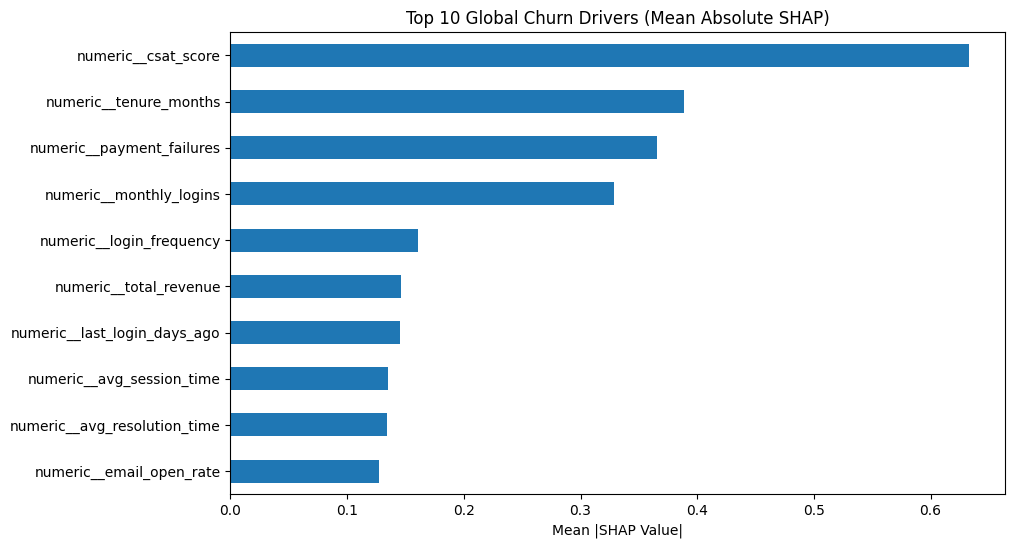

In [151]:
#Visualization
#To make this management‑friendly, you can plot a bar chart:

import matplotlib.pyplot as plt

global_shap_importance = shap_df.abs().mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
global_shap_importance.head(10).plot(kind='barh')
plt.title("Top 10 Global Churn Drivers (Mean Absolute SHAP)")
plt.xlabel("Mean |SHAP Value|")
plt.gca().invert_yaxis()
plt.show()


Dashboard Layout

1. Global Drivers (Management View)
- Horizontal bar chart of mean absolute SHAP values ( output table).

- Shows the top 10 churn drivers ranked by importance.

- Example: CSAT score, tenure, payment failures, monthly logins, etc.

- This answers: “What factors most influence churn across our customer base?”


2. Customer‑Level Summary (Operational View)
Table with:

- customer_id

- churn_probability

- risk_band (Low/Medium/High)

- top_drivers (3 most influential features with SHAP values)

                                 EXAMPLE 

- customer_id   churn_probability   risk_band   top_drivers
- CUST_05648    0.29                Medium      csat_score (+1.72), country_UK (-0.09), gender_0 (+0.05)
- CUST_09505    0.01                Low         marketing_click_rate (-0.26), csat_score (-0.77), login_frequency (-0.27)
- CUST_08510    0.36                Medium      country_Canada (+0.13), nps_score (+0.07), marketing_click_rate (+0.03)


This answers: “Which customers are at risk, and why?



3. Actionable Insights

- Customer Success Teams → filter by risk_band == "High" and see top drivers for each customer.

- Management → focus on global drivers (CSAT, tenure, payment failures) to guide strategy.

- Automation → pipeline can refresh weekly/monthly with new data, producing updated churn scores and explanations.

 What we’ve Achieved

- End‑to‑end churn prediction pipeline.

- Automated explanations at both individual and global levels.

- Ready for integration into dashboards (e.g., Power BI, Tableau, or even a simple Excel report).


In [152]:
#finalize the automation by banding customers into Low/Medium/High risk and producing a clean customer summary table with ID, probability, risk band, and top drivers.

import numpy as np
import pandas as pd

# Assume you already have churn_analysis_data, shap_df, and churn_probability

# Step 1: Risk Banding
results['risk_band'] = results['churn_probability'].apply(
    lambda p: 'Low' if p < 0.3 else 'Medium' if p < 0.6 else 'High'
)

# Step 2: Extract Top Drivers
feature_names = shap_df.columns

def extract_top_drivers(shap_row, feature_names, top_n=3):
    idx = np.argsort(np.abs(shap_row))[-top_n:]
    return ", ".join([f"{feature_names[i]} ({shap_row[i]:+.3f})" for i in idx])

results['top_drivers'] = shap_df.apply(
    lambda row: extract_top_drivers(row.values, feature_names), axis=1
)

# Step 3: Build Customer Summary Table
summary = results[['customer_id','churn_probability','risk_band','top_drivers']]

# Preview
print(summary.head())


  customer_id  churn_probability risk_band  \
0  CUST_05648           0.292725       Low   
1  CUST_09505           0.008853       Low   
2  CUST_08510           0.365800    Medium   
3  CUST_02131           0.020510       Low   
4  CUST_03347           0.161871       Low   

                                         top_drivers  
0  numeric__avg_resolution_time (+0.223), numeric...  
1  numeric__marketing_click_rate (-0.266), numeri...  
2  numeric__tenure_months (-0.288), numeric__avg_...  
3  numeric__monthly_logins (-0.300), numeric__pay...  
4  numeric__age (-0.363), numeric__csat_score (+1...  


In [153]:
#Filter High Risk

# Filter only High risk customers
high_risk_customers = summary[summary['risk_band'] == 'High']

# Preview
print(high_risk_customers.head())


    customer_id  churn_probability risk_band  \
124  CUST_09308           0.636069      High   
146  CUST_06599           0.608542      High   
187  CUST_03992           0.713899      High   
244  CUST_01296           0.614538      High   
307  CUST_03657           0.674440      High   

                                           top_drivers  
124  numeric__monthly_logins (-0.253), numeric__usa...  
146  numeric__login_frequency (+0.598), numeric__cs...  
187  numeric__csat_score (-0.291), numeric__tenure_...  
244  numeric__email_open_rate (+0.231), numeric__av...  
307  numeric__total_revenue (+0.340), numeric__paym...  


In [154]:
#Filter and Count
# Filter High risk customers
high_risk_customers = summary[summary['risk_band'] == 'High']

# Count customers in each band
risk_counts = summary['risk_band'].value_counts()

print("High Risk Customers:")
print(high_risk_customers[['customer_id','churn_probability','top_drivers']].head())

print("\nRisk Band Distribution:")
print(risk_counts)


High Risk Customers:
    customer_id  churn_probability  \
124  CUST_09308           0.636069   
146  CUST_06599           0.608542   
187  CUST_03992           0.713899   
244  CUST_01296           0.614538   
307  CUST_03657           0.674440   

                                           top_drivers  
124  numeric__monthly_logins (-0.253), numeric__usa...  
146  numeric__login_frequency (+0.598), numeric__cs...  
187  numeric__csat_score (-0.291), numeric__tenure_...  
244  numeric__email_open_rate (+0.231), numeric__av...  
307  numeric__total_revenue (+0.340), numeric__paym...  

Risk Band Distribution:
risk_band
Low       1831
Medium     154
High        15
Name: count, dtype: int64


 (Markdown Summaries)

 summarizing each stage:

# Customer Churn Project Summary

## Key Churn Drivers
- Short tenure (<1yr) + monthly contracts
- Technical complaints + low CSAT/NPS
- Individual customers with mid-range fees

## Segmentation
- High-value churners (top 25% revenue)
- Low-engagement churners (below median logins)
- Silent churners (no complaint logged)

## Retention Strategies
- Onboarding fixes for <1yr customers
- Contract incentives (monthly → annual)
- Technical support fast-track
- Loyalty rewards for high-value customers

## Operationalization
- Export churner IDs for outreach
- Build dashboards for monitoring
- Set alerts for churn probability >0.7

## Strategic Goal
Move from prediction → prevention → continuous learning


            

                      Stakeholder Presentation Storyboard

Slide 1: Executive Summary
Title: “Customer Churn Analysis & Retention Strategy”

Content:

- Churn rate identified: 585 customers at risk

- Key drivers: short tenure, monthly contracts, technical complaints, Individuals

- Strategic goal: move from prediction → prevention → continuous learning

- Visual: Big number (585 churners) + infographic showing “Prediction → Prevention → Learning”

Slide 2: EDA Findings
Title: “Who is Churning?”

Content:

- Seniors + Individuals dominate churn risk

- Monthly contracts = 50% churners

- Short tenure (<1yr) = highest risk group

- Visual: Bar chart of tenure buckets, pie chart of contract types

Slide 3: Predictive Modeling
Title: “Churn Prediction Model”

Content:

- Model accuracy: [Train score: 0.99775,  Test score: 0.8815 ]

- Churn probability distribution (histogram)

- Confidence levels for predictions

- Visual: Histogram of churn probability scores

Slide 4: Churn Drivers
Title: “Why Customers Leave”

Content:

- Technical complaints = 37%

- CSAT average = 2.9/5 (below neutral)

- NPS average = 21 (weak loyalty)

- Visual: Complaint breakdown bar chart + CSAT/NPS gauges

Slide 5: Segmentation
Title: “High-Risk Customer Segments”

Content:

- High-value churners (top 25% revenue)

- Low-engagement churners (below median logins)

- Silent churners (no complaint logged)

- Visual: Venn diagram or segmented bar chart

Slide 6: Retention Strategies
Title: “Retention Playbook”

Content:

- Onboarding fixes for <1yr customers

- Contract incentives (monthly → annual)

- Technical support fast-track

- Loyalty rewards for high-value customers

- Visual: Matrix (Segment → Action → Expected Outcome)

Slide 7: Operationalization
Title: “Making It Actionable”

Content:

- Export churner IDs for outreach

- Dashboards for monitoring churn probability, complaints, engagement

- Alerts for churn probability >0.7

- Visual: Screenshot of dashboard mock-up

Slide 8: Impact Measurement
Title: “Measuring Success”

Content:

- KPIs: retention rate, revenue saved, CSAT/NPS improvement

- Compare retention across segments (Seniors vs Young, Monthly vs Yearly)

- Visual: KPI dashboard with % retention and revenue saved

Slide 9: Closing the Loop
Title: “Continuous Learning”

Content:

- Feedback cycle: Predict → Segment → Act → Measure → Retrain

- Visual: Circular workflow diagram

Slide 10: Call to Action
Title: “Next Steps”

Content:

- Approve resources for retention campaigns

- Support dashboard implementation

- Agree on quarterly review cycle

- Visual: Checklist graphic

     Goal
By the end of the deck, stakeholders will clearly see:

Where churn is happening

Why it’s happening

What actions you’ll take

How success will be measured

In [155]:
X.columns


Index(['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months',
       'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'total_revenue_to_date',
       'login_frequency', 'support_intensity', 'is_high_value', 'age_group',
       'tenure_bucket'],
      dtype='object')

In [156]:
X.head()


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,marketing_click_rate,nps_score,survey_response,referral_count,total_revenue_to_date,login_frequency,support_intensity,is_high_value,age_group,tenure_bucket
0,0,68,Bangladesh,London,SME,22,Web,Monthly,26,7,...,0.40,27,Satisfied,1,30,1.181818,0.181818,0,Senior,1-3yrs
1,1,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,...,0.33,-19,Neutral,2,30,0.777778,0.111111,0,Adult,<1yr
2,0,24,Germany,New York,SME,58,Web,Yearly,19,5,...,0.49,80,Neutral,1,20,0.327586,0.017241,0,Youth,3-5yrs
3,0,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,...,0.15,100,Neutral,0,30,1.789474,0.157895,0,Adult,1-3yrs
4,0,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,...,0.44,21,Unsatisfied,1,50,0.384615,0.000000,1,Senior,3-5yrs


Snowflakes connection process

In [157]:
import snowflake.connector

In [158]:
import snowflake.connector

conn = snowflake.connector.connect(
    user="Snowflakeadmin",
    password="4ikcaAgjW72He9a",
    account="uvxupbi-aq60096",   # combine org + account name
    warehouse="COMPUTE_WH",
    database="CUSTOMER_DB",
    schema="PUBLIC"
)


In [159]:
cursor = conn.cursor()
cursor.execute("CREATE DATABASE IF NOT EXISTS CUSTOMER_DB")
cursor.execute("USE DATABASE CUSTOMER_DB")
cursor.execute("USE SCHEMA PUBLIC")
cursor.close()


True

In [160]:
cursor = conn.cursor()
cursor.execute("""
    CREATE OR REPLACE TABLE CUSTOMER_FEATURES (
        customer_id STRING,
        gender INT,
        age INT,
        country STRING,
        city STRING,
        customer_segment STRING,
        tenure_months INT,
        signup_channel STRING,
        contract_type STRING,
        monthly_logins INT,
        weekly_active_days INT,
        marketing_click_rate FLOAT,
        nps_score INT,
        survey_response STRING,
        referral_count INT,
        total_revenue_to_date FLOAT,
        login_frequency FLOAT,
        support_intensity FLOAT,
        is_high_value INT,
        age_group STRING,
        tenure_bucket STRING
    )
""")
cursor.close()


True

In [161]:
# Map 0 -> Male, 1 -> Female
X['gender'] = X['gender'].map({0: 'Male', 1: 'Female'})

# Check the first few rows to confirm
X[['gender']].head()


,gender
0,Male
1,Female
2,Male
3,Male
4,Male


In [162]:
print(X['gender'].unique())


['Male' 'Female']


In [163]:
# Standardize column names: lowercase, underscores, no spaces
X.columns = [c.strip().replace(" ", "_").lower() for c in X.columns]

# Check the result
print(X.columns.tolist())


['gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'total_revenue_to_date', 'login_frequency', 'support_intensity', 'is_high_value', 'age_group', 'tenure_bucket']


In [164]:
# Add customer_id column back into X
X['customer_id'] = customer_ids

# Move it to the front for clarity
cols = ['customer_id'] + [c for c in X.columns if c != 'customer_id']
X = X[cols]

# Verify
print(X.head())


  customer_id  gender  age     country      city customer_segment  \
0  CUST_00001    Male   68  Bangladesh    London              SME   
1  CUST_00002  Female   57      Canada    Sydney       Individual   
2  CUST_00003    Male   24     Germany  New York              SME   
3  CUST_00004    Male   49   Australia     Dhaka       Individual   
4  CUST_00005    Male   65  Bangladesh     Delhi       Individual   

   tenure_months signup_channel contract_type  monthly_logins  ...  \
0             22            Web       Monthly              26  ...   
1              9         Mobile       Monthly               7  ...   
2             58            Web        Yearly              19  ...   
3             19         Mobile        Yearly              34  ...   
4             52            Web       Monthly              20  ...   

   marketing_click_rate  nps_score  survey_response  referral_count  \
0                  0.40         27        Satisfied               1   
1                  0.3

In [165]:
# Convert all DataFrame column names to uppercase
X.columns = [c.upper() for c in X.columns]

# Verify
print(X.columns.tolist())


['CUSTOMER_ID', 'GENDER', 'AGE', 'COUNTRY', 'CITY', 'CUSTOMER_SEGMENT', 'TENURE_MONTHS', 'SIGNUP_CHANNEL', 'CONTRACT_TYPE', 'MONTHLY_LOGINS', 'WEEKLY_ACTIVE_DAYS', 'AVG_SESSION_TIME', 'FEATURES_USED', 'USAGE_GROWTH_RATE', 'LAST_LOGIN_DAYS_AGO', 'MONTHLY_FEE', 'TOTAL_REVENUE', 'PAYMENT_METHOD', 'PAYMENT_FAILURES', 'DISCOUNT_APPLIED', 'PRICE_INCREASE_LAST_3M', 'SUPPORT_TICKETS', 'AVG_RESOLUTION_TIME', 'COMPLAINT_TYPE', 'CSAT_SCORE', 'ESCALATIONS', 'EMAIL_OPEN_RATE', 'MARKETING_CLICK_RATE', 'NPS_SCORE', 'SURVEY_RESPONSE', 'REFERRAL_COUNT', 'TOTAL_REVENUE_TO_DATE', 'LOGIN_FREQUENCY', 'SUPPORT_INTENSITY', 'IS_HIGH_VALUE', 'AGE_GROUP', 'TENURE_BUCKET']


In [166]:
cursor = conn.cursor()
cursor.execute("""
    CREATE OR REPLACE TABLE CUSTOMER_FEATURES (
        CUSTOMER_ID STRING,
        GENDER STRING,
        AGE INT,
        COUNTRY STRING,
        CITY STRING,
        CUSTOMER_SEGMENT STRING,
        TENURE_MONTHS INT,
        SIGNUP_CHANNEL STRING,
        CONTRACT_TYPE STRING,
        MONTHLY_LOGINS INT,
        WEEKLY_ACTIVE_DAYS INT,
        AVG_SESSION_TIME FLOAT,
        FEATURES_USED INT,
        USAGE_GROWTH_RATE FLOAT,
        LAST_LOGIN_DAYS_AGO INT,
        MONTHLY_FEE FLOAT,
        TOTAL_REVENUE FLOAT,
        PAYMENT_METHOD STRING,
        PAYMENT_FAILURES INT,
        DISCOUNT_APPLIED INT,
        PRICE_INCREASE_LAST_3M INT,
        SUPPORT_TICKETS INT,
        AVG_RESOLUTION_TIME FLOAT,
        COMPLAINT_TYPE STRING,
        CSAT_SCORE FLOAT,
        ESCALATIONS INT,
        EMAIL_OPEN_RATE FLOAT,
        MARKETING_CLICK_RATE FLOAT,
        NPS_SCORE INT,
        SURVEY_RESPONSE STRING,
        REFERRAL_COUNT INT,
        TOTAL_REVENUE_TO_DATE FLOAT,
        LOGIN_FREQUENCY FLOAT,
        SUPPORT_INTENSITY FLOAT,
        IS_HIGH_VALUE INT,
        AGE_GROUP STRING,
        TENURE_BUCKET STRING
    )
""")


In [167]:
from snowflake.connector.pandas_tools import write_pandas

success, nchunks, nrows, _ = write_pandas(conn, X, "CUSTOMER_FEATURES")
print(f"Loaded {nrows} rows into Snowflake")


Loaded 10000 rows into Snowflake


In [168]:
cursor = conn.cursor()
cursor.execute("""
    CREATE OR REPLACE TABLE CUSTOMER_CHURN_SUMMARY (
        CUSTOMER_ID STRING,
        CHURN_PROBABILITY FLOAT,
        RISK_BAND STRING,
        TOP_DRIVERS STRING
    )
""")


In [169]:
summary_df = summary


In [170]:
print(summary_df.head())
print(summary_df.dtypes)


  customer_id  churn_probability risk_band  \
0  CUST_05648           0.292725       Low   
1  CUST_09505           0.008853       Low   
2  CUST_08510           0.365800    Medium   
3  CUST_02131           0.020510       Low   
4  CUST_03347           0.161871       Low   

                                         top_drivers  
0  numeric__avg_resolution_time (+0.223), numeric...  
1  numeric__marketing_click_rate (-0.266), numeri...  
2  numeric__tenure_months (-0.288), numeric__avg_...  
3  numeric__monthly_logins (-0.300), numeric__pay...  
4  numeric__age (-0.363), numeric__csat_score (+1...  
customer_id           object
churn_probability    float32
risk_band             object
top_drivers           object
dtype: object


In [171]:
cursor = conn.cursor()
cursor.execute("""
    CREATE OR REPLACE TABLE CUSTOMER_CHURN_SUMMARY (
        CUSTOMER_ID STRING,
        CHURN_PROBABILITY FLOAT,
        RISK_BAND STRING,
        TOP_DRIVERS STRING
    )
""")


In [172]:
summary_df.columns = [c.upper() for c in summary_df.columns]


In [173]:
from snowflake.connector.pandas_tools import write_pandas

success, nchunks, nrows, _ = write_pandas(conn, summary_df, "CUSTOMER_CHURN_SUMMARY")
print(f"Loaded {nrows} rows into Snowflake")


Loaded 2000 rows into Snowflake


Automation Stage

Python script outline that ties together data refresh, model scoring, and Snowflake load

In [174]:
features_df = df.copy()   # just use the raw dataset


In [175]:
print(df.columns)


Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn', 'total_revenue_to_date',
       'login_frequency', 'support_intensity', 'is_high_value', 'age_group',
       'tenure_bucket'],
      dtype='object')


In [176]:
print('churn' in X.columns)


False


In [177]:
# Check if 'churn' is still in your features
print('churn' in X.columns)

# Inspect the dtypes of your features
print(X.dtypes)

# Compare with what your pipeline expects
print(pipeline.named_steps['preprocessor'].transformers)


False
CUSTOMER_ID                 object
GENDER                      object
AGE                          int64
COUNTRY                     object
CITY                        object
CUSTOMER_SEGMENT            object
TENURE_MONTHS                int64
SIGNUP_CHANNEL              object
CONTRACT_TYPE               object
MONTHLY_LOGINS               int64
WEEKLY_ACTIVE_DAYS           int64
AVG_SESSION_TIME           float64
FEATURES_USED                int64
USAGE_GROWTH_RATE          float64
LAST_LOGIN_DAYS_AGO          int64
MONTHLY_FEE                  int64
TOTAL_REVENUE                int64
PAYMENT_METHOD              object
PAYMENT_FAILURES             int64
DISCOUNT_APPLIED           float64
PRICE_INCREASE_LAST_3M     float64
SUPPORT_TICKETS              int64
AVG_RESOLUTION_TIME        float64
COMPLAINT_TYPE              object
CSAT_SCORE                 float64
ESCALATIONS                  int64
EMAIL_OPEN_RATE            float64
MARKETING_CLICK_RATE       float64
NPS_SCORE     

In [178]:
categorical_cols = [
    'gender','country','city','customer_segment','signup_channel',
    'contract_type','payment_method','complaint_type',
    'age_group','tenure_bucket','survey_response',
    'discount_applied','price_increase_last_3m'   # move these here
]

numeric_cols = [
    'age','tenure_months','monthly_logins','weekly_active_days',
    'avg_session_time','features_used','usage_growth_rate',
    'last_login_days_ago','monthly_fee','total_revenue',
    'payment_failures','support_tickets','avg_resolution_time',
    'csat_score','escalations','email_open_rate','marketing_click_rate',
    'nps_score','referral_count','total_revenue_to_date',
    'login_frequency','support_intensity','is_high_value'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


In [179]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])


In [180]:
pipeline.fit(X_train, y_train)


C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:28:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'tenure_months',
                                                   'monthly_logins',
                                                   'weekly_active_days',
                                                   'avg_session_time',
                                                   'features_used',
                                                   'usage_growth_rate',
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'total_revenue',
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_o...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [181]:
def transform_features(df):
    # Age group buckets
    df['age_group'] = pd.cut(df['age'], bins=[0,25,40,60,100],
                             labels=['Youth','Adult','Middle','Senior'])

    # High value flag
    df['is_high_value'] = (df['monthly_fee'] > 70).astype(int)

    # Tenure buckets
    df['tenure_bucket'] = pd.cut(df['tenure_months'], bins=[0,12,36,60,120],
                                 labels=['<1yr','1-3yrs','3-5yrs','5+yrs'])

    # Total revenue to date
    df['total_revenue_to_date'] = df['monthly_fee'] * df['tenure_months']

    # Login frequency
    df['login_frequency'] = df['monthly_logins'] / df['tenure_months']

    # Support intensity
    df['support_intensity'] = df['support_tickets'] / df['tenure_months']

    return df


In [182]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Customer Churn data\customer_churn_business_dataset.csv")
df = transform_features(df)

X = df.drop(columns=['churn'])
y_pred_proba = pipeline.predict_proba(X)[:,1]


In [183]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Customer Churn data\customer_churn_business_dataset.csv")
df = transform_features(df)

X = df.drop(columns=['churn'])
y = df['churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [184]:
pipeline.fit(X_train, y_train)


C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:28:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'tenure_months',
                                                   'monthly_logins',
                                                   'weekly_active_days',
                                                   'avg_session_time',
                                                   'features_used',
                                                   'usage_growth_rate',
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'total_revenue',
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_o...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [185]:
print("Train score:", pipeline.score(X_train, y_train))
print("Test score:", pipeline.score(X_test, y_test))


Train score: 0.99775
Test score: 0.8815


In [186]:
# Score full dataset
y_pred_proba = pipeline.predict_proba(X)[:,1]

# Risk banding
risk_band = pd.Series(y_pred_proba).apply(
    lambda p: 'Low' if p < 0.3 else 'Medium' if p < 0.6 else 'High'
)

# Summary DataFrame
summary_df = pd.DataFrame({
    'CUSTOMER_ID': df['customer_id'],
    'CHURN_PROBABILITY': y_pred_proba,
    'RISK_BAND': risk_band
})


In [187]:
import pandas as pd
from snowflake.connector import connect
from snowflake.connector.pandas_tools import write_pandas

# Step 1: Connect to Snowflake
conn = connect(
    user="Snowflakeadmin",
    password="4ikcaAgjW72He9a",
    account="uvxupbi-aq60096",
    warehouse="COMPUTE_WH",
    database="CUSTOMER_DB",
    schema="PUBLIC"
)

# Step 2: Load Kaggle churn dataset
df = pd.read_csv(r"C:\Users\HP\Downloads\Customer Churn data\customer_churn_business_dataset.csv")

# Step 3: Apply feature engineering
df = transform_features(df)

# Step 4: Model scoring using your trained pipeline
X_full = df.drop(columns=['churn'])
y_pred_proba = pipeline.predict_proba(X_full)[:,1]

# Step 5: Risk banding
risk_band = pd.Series(y_pred_proba).apply(
    lambda p: 'Low' if p < 0.3 else 'Medium' if p < 0.6 else 'High'
)

# Step 6: Build summary DataFrame
summary_df = pd.DataFrame({
    'CUSTOMER_ID': df['customer_id'],
    'CHURN_PROBABILITY': y_pred_proba,
    'RISK_BAND': risk_band
})

# Step 7: Load into Snowflake
summary_df.columns = [c.upper() for c in summary_df.columns]
success, nchunks, nrows, _ = write_pandas(conn, summary_df, "CUSTOMER_CHURN_SUMMARY")
print(f"Automation run complete: {nrows} rows loaded.")



Automation run complete: 10000 rows loaded.


In [188]:
from prefect import flow

@flow
def churn_pipeline():
    conn_params = {
        "user": "Snowflakeadmin",
        "password": "4ikcaAgjW72He9a",
        "account": "uvxupbi-aq60096",
        "warehouse": "COMPUTE_WH",
        "database": "CUSTOMER_DB",
        "schema": "PUBLIC"
    }

    summary_df = automate_churn_scoring(
        pipeline,
        r"C:\Users\HP\Downloads\Customer Churn data\customer_churn_business_dataset.csv",
        conn_params
    )
    print("Automation run complete:", len(summary_df), "rows loaded.")


In [189]:
!prefect deployment build churn_pipeline.py:churn_pipeline -n "daily-churn"
!prefect deployment apply churn_pipeline-deployment.yaml
!prefect schedule add "daily-churn" --cron "0 8 * * *"


+- Error ---------------------------------------------------------------------+
| Unknown command "build". Available commands: schedule, inspect, ls, run,    |
| delete.                                                                     |
+-----------------------------------------------------------------------------+
+- Error ---------------------------------------------------------------------+
| Unknown command "apply". Available commands: schedule, inspect, ls, run,    |
| delete.                                                                     |
+-----------------------------------------------------------------------------+
+- Error ---------------------------------------------------------------------+
| Unknown command "schedule". Did you mean "shell"? Available commands:       |
| deploy, init, flow, flows, flow-run, flow-runs, deployment, deployments,    |
| ...                                                                         |
+---------------------------------------

In [190]:
from prefect import flow

@flow
def churn_pipeline():
    conn_params = {
        "user": "Snowflakeadmin",
        "password": "4ikcaAgjW72He9a",
        "account": "uvxupbi-aq60096",
        "warehouse": "COMPUTE_WH",
        "database": "CUSTOMER_DB",
        "schema": "PUBLIC"
    }

    summary_df = automate_churn_scoring(
        pipeline,
        r"C:\Users\HP\Downloads\Customer Churn data\customer_churn_business_dataset.csv",
        conn_params
    )
    print("Automation run complete:", len(summary_df), "rows loaded.")


In [191]:
import snowflake.connector
import pandas as pd

conn = snowflake.connector.connect(
    user="Snowflakeadmin",
    password="4ikcaAgjW72He9a",
    account="uvxupbi-aq60096",   # combine org + account name
    warehouse="COMPUTE_WH",
    database="CUSTOMER_DB",
    schema="PUBLIC"
)


# Example: Query CUSTOMER_CHURN_SUMMARY
query = "SELECT * FROM CUSTOMER_CHURN_SUMMARY LIMIT 20;"
df_summary = pd.read_sql(query, conn)
print(df_summary.head())

# Example: Query CUSTOMER_FEATURES
query = "SELECT * FROM CUSTOMER_FEATURES LIMIT 20;"
df_features = pd.read_sql(query, conn)
print(df_features.head())

# Close connection when done
conn.close()


C:\Users\HP\AppData\Local\Temp\ipykernel_11928\793969762.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_summary = pd.read_sql(query, conn)


  CUSTOMER_ID  CHURN_PROBABILITY RISK_BAND  \
0  CUST_05648           0.292725       Low   
1  CUST_09505           0.008853       Low   
2  CUST_08510           0.365800    Medium   
3  CUST_02131           0.020510       Low   
4  CUST_03347           0.161871       Low   

                                         TOP_DRIVERS  
0  numeric__avg_resolution_time (+0.223), numeric...  
1  numeric__marketing_click_rate (-0.266), numeri...  
2  numeric__tenure_months (-0.288), numeric__avg_...  
3  numeric__monthly_logins (-0.300), numeric__pay...  
4  numeric__age (-0.363), numeric__csat_score (+1...  


C:\Users\HP\AppData\Local\Temp\ipykernel_11928\793969762.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_features = pd.read_sql(query, conn)


  CUSTOMER_ID  GENDER  AGE     COUNTRY      CITY CUSTOMER_SEGMENT  \
0  CUST_00001    Male   68  Bangladesh    London              SME   
1  CUST_00002  Female   57      Canada    Sydney       Individual   
2  CUST_00003    Male   24     Germany  New York              SME   
3  CUST_00004    Male   49   Australia     Dhaka       Individual   
4  CUST_00005    Male   65  Bangladesh     Delhi       Individual   

   TENURE_MONTHS SIGNUP_CHANNEL CONTRACT_TYPE  MONTHLY_LOGINS  ...  \
0             22            Web       Monthly              26  ...   
1              9         Mobile       Monthly               7  ...   
2             58            Web        Yearly              19  ...   
3             19         Mobile        Yearly              34  ...   
4             52            Web       Monthly              20  ...   

   MARKETING_CLICK_RATE  NPS_SCORE  SURVEY_RESPONSE  REFERRAL_COUNT  \
0                  0.40         27        Satisfied               1   
1                  0.3

Scheduling Options
1. Windows Task Scheduler (simple daily run)